In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
 
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
 
# Folder output (dibuat otomatis kalau belum ada, relatif ke cwd notebook ini)
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# Konfigurasi CV global, dipakai konsisten di baseline & loop persentil
N_SPLITS = 5  # 5 kelas -> 5-fold lebih aman untuk SMOTE varian dibanding 10-fold
RANDOM_STATE = 42
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
 

/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/PengamanJaringan/dataset/Dataset_for_paper.csv',encoding='latin-1')
data

,file_name,Class,ACCESS_BACKGROUND_LOCATION,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MEDIA_LOCATION,ACCESS_NETWORK_STATE,ACCESS_NOTIFICATION_POLICY,ACCESS_WIFI_STATE,...,BIND_DIRECTORY_SEARCH,BROADCAST_CLOSE_SYSTEM_DIALOGS,CAPTURE_SECURE_VIDEO_OUTPUT,WRITE_CLIPS,FLAG_GRANT_READ_URI_PERMISSION,FORCE_STOP_PACKAGES,GET_CLIPS,GET_INTENT_SENDER_INTENT,GET_TOP_AVTIVITY_INFO,INTERNAL_SYSTEM_WINDOW
0,0000000mapk00001_AndroidManifest.xml,0,0,1,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0000000mapk00003_AndroidManifest.xml,0,0,1,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0000000mapk00004_AndroidManifest.xml,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0000000mapk00005_AndroidManifest.xml,0,0,1,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0000000mapk00006_AndroidManifest.xml,0,0,1,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126438,xcxin.filexpert_AndroidManifest.xml,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
126439,xyz.studiox.pixels_AndroidManifest.xml,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
126440,you.in.spark.energy_AndroidManifest.xml,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
126441,za.co.prosense.impression_AndroidManifest.xml,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data.isnull().sum()

file_name                     0
Class                         0
ACCESS_BACKGROUND_LOCATION    0
ACCESS_COARSE_LOCATION        0
ACCESS_FINE_LOCATION          0
                             ..
FORCE_STOP_PACKAGES           0
GET_CLIPS                     0
GET_INTENT_SENDER_INTENT      0
GET_TOP_AVTIVITY_INFO         0
INTERNAL_SYSTEM_WINDOW        0
Length: 191, dtype: int64

In [4]:
data['Class'].value_counts()

Class
1    72392
0    54051
Name: count, dtype: int64

In [5]:
data = data.drop(columns=['file_name'])
data

,Class,ACCESS_BACKGROUND_LOCATION,ACCESS_COARSE_LOCATION,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MEDIA_LOCATION,ACCESS_NETWORK_STATE,ACCESS_NOTIFICATION_POLICY,ACCESS_WIFI_STATE,ACCOUNT_MANAGER,...,BIND_DIRECTORY_SEARCH,BROADCAST_CLOSE_SYSTEM_DIALOGS,CAPTURE_SECURE_VIDEO_OUTPUT,WRITE_CLIPS,FLAG_GRANT_READ_URI_PERMISSION,FORCE_STOP_PACKAGES,GET_CLIPS,GET_INTENT_SENDER_INTENT,GET_TOP_AVTIVITY_INFO,INTERNAL_SYSTEM_WINDOW
0,0,0,1,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126438,1,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
126439,1,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
126440,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
126441,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
data['Class'].value_counts()

Class
1    72392
0    54051
Name: count, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (101154, 189)
Shape of X_test: (25289, 189)
Shape of y_train: (101154,)
Shape of y_test: (25289,)


In [8]:

print(f"Shape X_train : {X_train.shape}")
print(f"Shape X_test  : {X_test.shape}")
print("\nDistribusi y_train:")
print(y_train.value_counts())
print("\nDistribusi y_test:")
print(y_test.value_counts())
 
class_labels = sorted(y_train.unique())
print(f"\nClass labels: {class_labels}")

Shape X_train : (101154, 189)
Shape X_test  : (25289, 189)

Distribusi y_train:
Class
1    57913
0    43241
Name: count, dtype: int64

Distribusi y_test:
Class
1    14479
0    10810
Name: count, dtype: int64

Class labels: [np.int64(0), np.int64(1)]


In [9]:

# %%
def plot_confusion_matrix(y_true, y_pred, title, class_labels):
    """Plot confusion matrix raw count + normalized berdampingan."""
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
 
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Raw Count')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
 
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[1], linewidths=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Normalized (per True Class)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')
 
    plt.tight_layout()
    plt.show()
 
 
def run_manual_cv(pipeline_steps, X, y, skf, group_label, n_features, model_name):
    """
    Jalankan Stratified K-Fold CV secara manual (loop skf.split sendiri),
    sehingga setiap fold menghasilkan:
    - prediksi di fold validasi (digabung jadi prediksi out-of-fold, dipakai
      untuk classification_report & confusion matrix)
    - skor metrik KHUSUS fold itu (dipakai untuk analisis statistik per fold)
 
    Resampling/scaling (jika ada di pipeline_steps) hanya pernah melihat
    fold training di setiap iterasi -> tidak ada data leakage ke fold
    validasi.
 
    Parameters
    ----------
    pipeline_steps : list of (name, estimator) tuples, format sklearn Pipeline
    X, y           : data training (sebelum displit CV)
    skf            : StratifiedKFold instance
    group_label    : label kombinasi (misal: 'Baseline' atau persentase fitur)
    n_features     : jumlah fitur yang dipakai di kombinasi ini
    model_name     : nama model (untuk pencatatan)
 
    Returns
    -------
    y_pred_oof   : np.array, prediksi out-of-fold (urutan sama dengan y)
    fold_records : list of dict, satu dict per fold
    """
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
 
    y_pred_oof = np.empty(len(y), dtype=y.dtype)
    fold_records = []
 
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
 
        # Pipeline baru per fold -> tidak ada state yang "nempel" dari
        # fold sebelumnya (terutama untuk scaler/resampler).
        fold_pipeline = ImbPipeline(pipeline_steps) if any(
            step_name in ("resampling",) for step_name, _ in pipeline_steps
        ) else Pipeline(pipeline_steps)
 
        fold_pipeline.fit(X_tr, y_tr)
        y_pred_val = fold_pipeline.predict(X_val)
        y_pred_oof[val_idx] = y_pred_val
 
        fold_records.append({
            'Group'              : group_label,   # 'Baseline' atau persentil (%)
            'N Fitur'            : n_features,
            'Model'              : model_name,
            'Fold'               : fold_idx,
            'Accuracy'           : accuracy_score(y_val, y_pred_val),
            'F1 Macro'           : f1_score(y_val, y_pred_val, average='macro', zero_division=0),
            'F1 Weighted'        : f1_score(y_val, y_pred_val, average='weighted', zero_division=0),
            'Precision Macro'    : precision_score(y_val, y_pred_val, average='macro', zero_division=0),
            'Precision Weighted' : precision_score(y_val, y_pred_val, average='weighted', zero_division=0),
            'Recall Macro'       : recall_score(y_val, y_pred_val, average='macro', zero_division=0),
            'Recall Weighted'    : recall_score(y_val, y_pred_val, average='weighted', zero_division=0),
            'N Val Samples'      : len(val_idx),
        })
 
    return y_pred_oof, fold_records
 
 
def summarize_cv_report(y_true, y_pred_oof, fold_records, group_label, n_features, model_name, cv_time):
    """Ringkas hasil CV (rata-rata + std antar fold) jadi satu dict."""
    report = classification_report(y_true, y_pred_oof, output_dict=True, zero_division=0)
    fold_df = pd.DataFrame(fold_records)
    return {
        'Group'                     : group_label,
        'N Fitur'                   : n_features,
        'Model'                     : model_name,
        'Accuracy'                  : report['accuracy'],
        'F1 Macro'                  : report['macro avg']['f1-score'],
        'F1 Weighted'               : report['weighted avg']['f1-score'],
        'Precision Macro'           : report['macro avg']['precision'],
        'Precision Weighted'        : report['weighted avg']['precision'],
        'Recall Macro'              : report['macro avg']['recall'],
        'Recall Weighted'           : report['weighted avg']['recall'],
        'F1 Macro Std (antar fold)' : fold_df['F1 Macro'].std(),
        'CV Time'                   : round(cv_time, 4),
    }
 
 
def evaluate_holdout(pipeline_steps, X_train_fit, y_train_fit, X_test_fit, y_test_fit,
                      group_label, n_features, model_name):
    """Fit pipeline di SELURUH data training, evaluasi di hold-out test asli."""
    pipeline = ImbPipeline(pipeline_steps) if any(
        step_name in ("resampling",) for step_name, _ in pipeline_steps
    ) else Pipeline(pipeline_steps)
 
    start = time.time()
    pipeline.fit(X_train_fit, y_train_fit)
    train_time = time.time() - start
 
    start = time.time()
    y_pred_test = pipeline.predict(X_test_fit)
    test_time = time.time() - start
 
    report_test = classification_report(y_test_fit, y_pred_test, output_dict=True, zero_division=0)
 
    result = {
        'Group'              : group_label,
        'N Fitur'            : n_features,
        'Model'              : model_name,
        'Accuracy'           : report_test['accuracy'],
        'F1 Macro'           : report_test['macro avg']['f1-score'],
        'F1 Weighted'        : report_test['weighted avg']['f1-score'],
        'Precision Macro'    : report_test['macro avg']['precision'],
        'Precision Weighted' : report_test['weighted avg']['precision'],
        'Recall Macro'       : report_test['macro avg']['recall'],
        'Recall Weighted'    : report_test['weighted avg']['recall'],
        'Training Time'      : round(train_time, 4),
        'Testing Time'       : round(test_time, 4),
    }
    return result, y_pred_test
 


  Baseline (tanpa FS, tanpa resampling) — RandomForest
  CV Time (5-fold) : 78.5045s

  Skor per fold — RandomForest (Baseline):
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9630    0.9622       0.9630           0.9623        0.9621
    2          20231    0.9618    0.9609       0.9618           0.9612        0.9607
    3          20231    0.9629    0.9621       0.9629           0.9621        0.9620
    4          20231    0.9629    0.9621       0.9629           0.9621        0.9621
    5          20230    0.9623    0.9615       0.9623           0.9616        0.9614

  Classification Report (CV, out-of-fold) — RandomForest (Baseline):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     43241
           1       0.97      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg      

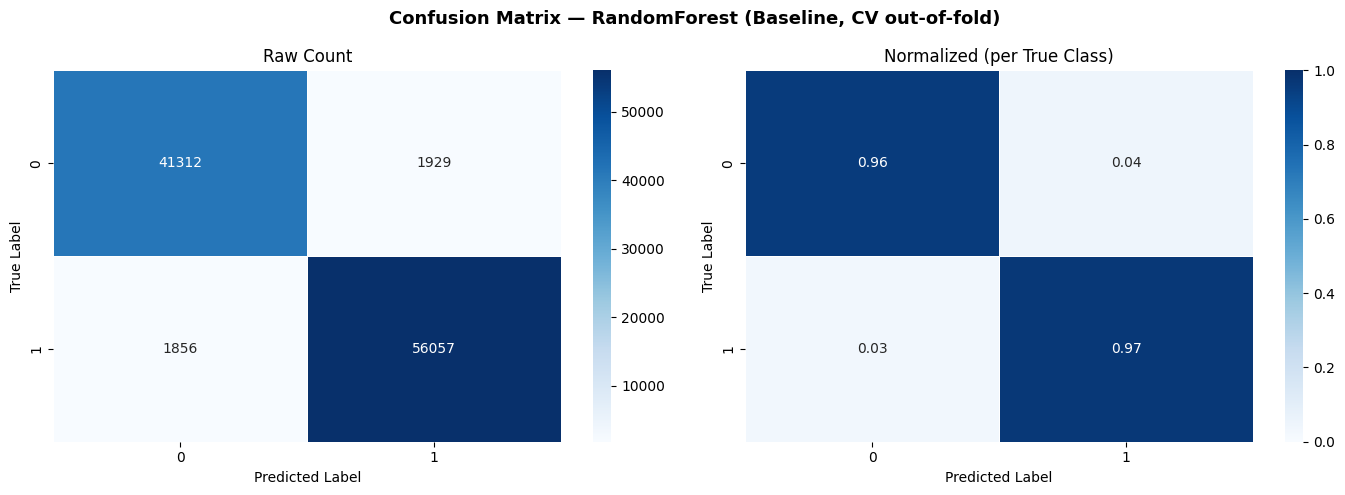


  Classification Report (Hold-out Test) — RandomForest (Baseline):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.97     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.97      0.97      0.97     25289



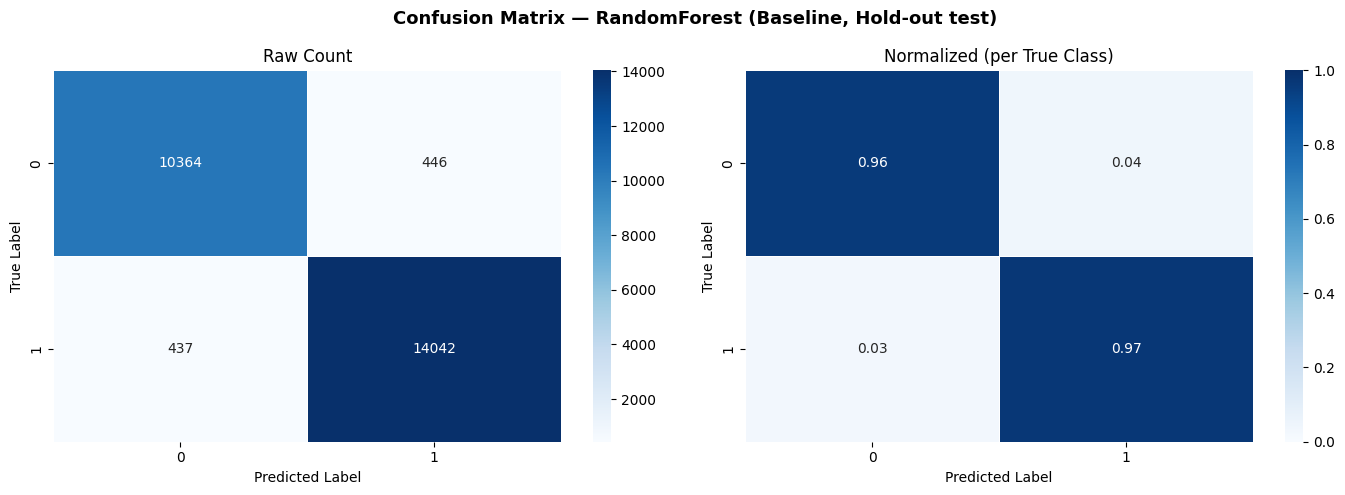


  Baseline (tanpa FS, tanpa resampling) — XGBoost
  CV Time (5-fold) : 6.9684s

  Skor per fold — XGBoost (Baseline):
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9585    0.9575       0.9584           0.9589        0.9563
    2          20231    0.9587    0.9577       0.9587           0.9593        0.9563
    3          20231    0.9600    0.9591       0.9600           0.9602        0.9580
    4          20231    0.9605    0.9596       0.9605           0.9606        0.9586
    5          20230    0.9596    0.9586       0.9596           0.9598        0.9576

  Classification Report (CV, out-of-fold) — XGBoost (Baseline):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     43241
           1       0.96      0.97      0.96     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96 

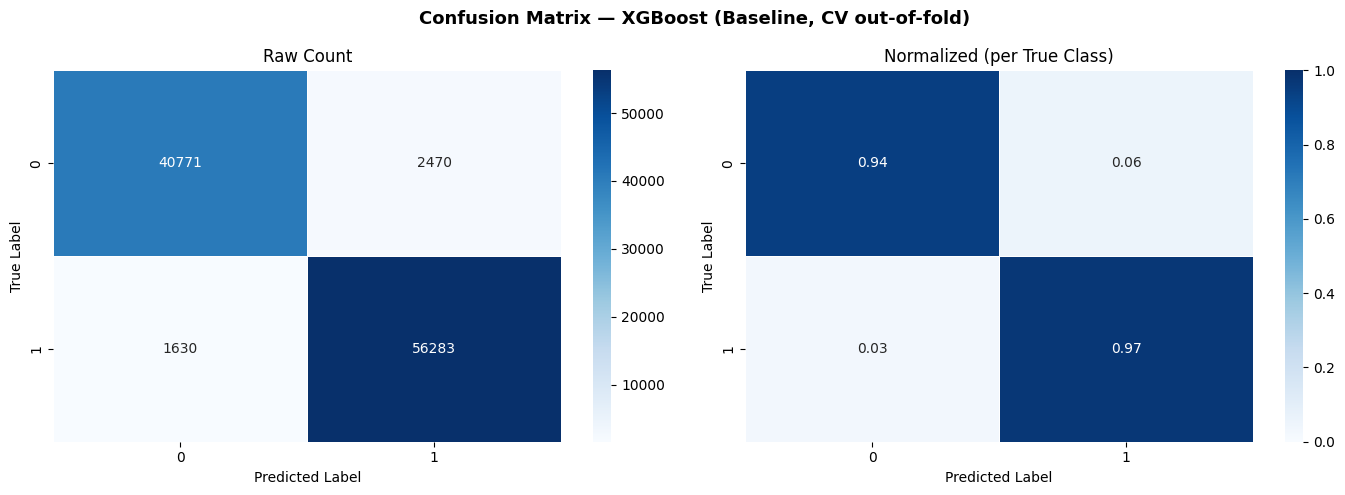


  Classification Report (Hold-out Test) — XGBoost (Baseline):
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



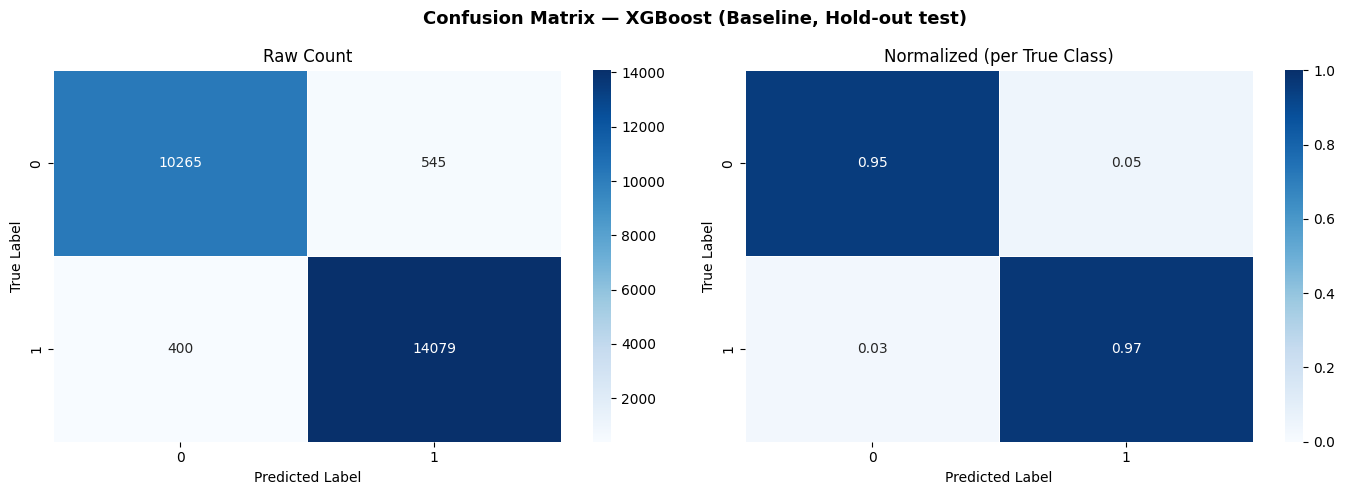


  Baseline (tanpa FS, tanpa resampling) — LightGBM
  CV Time (5-fold) : 8.3433s

  Skor per fold — LightGBM (Baseline):
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9596    0.9587       0.9596           0.9594        0.9580
    2          20231    0.9591    0.9581       0.9590           0.9591        0.9572
    3          20231    0.9612    0.9603       0.9612           0.9608        0.9598
    4          20231    0.9599    0.9590       0.9599           0.9595        0.9586
    5          20230    0.9604    0.9595       0.9603           0.9599        0.9590

  Classification Report (CV, out-of-fold) — LightGBM (Baseline):
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.

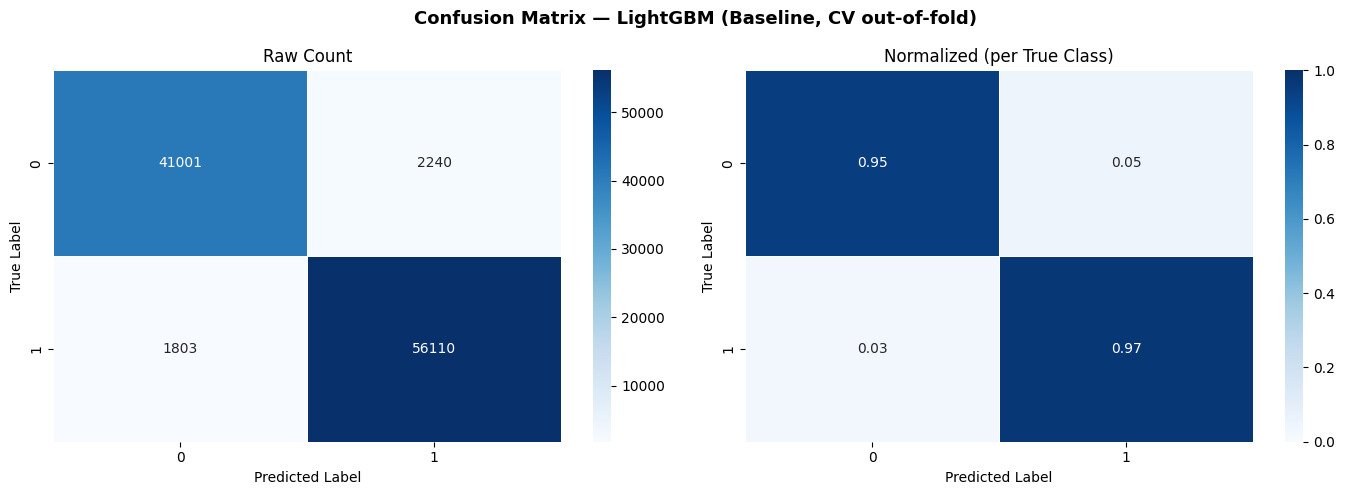


  Classification Report (Hold-out Test) — LightGBM (Baseline):
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



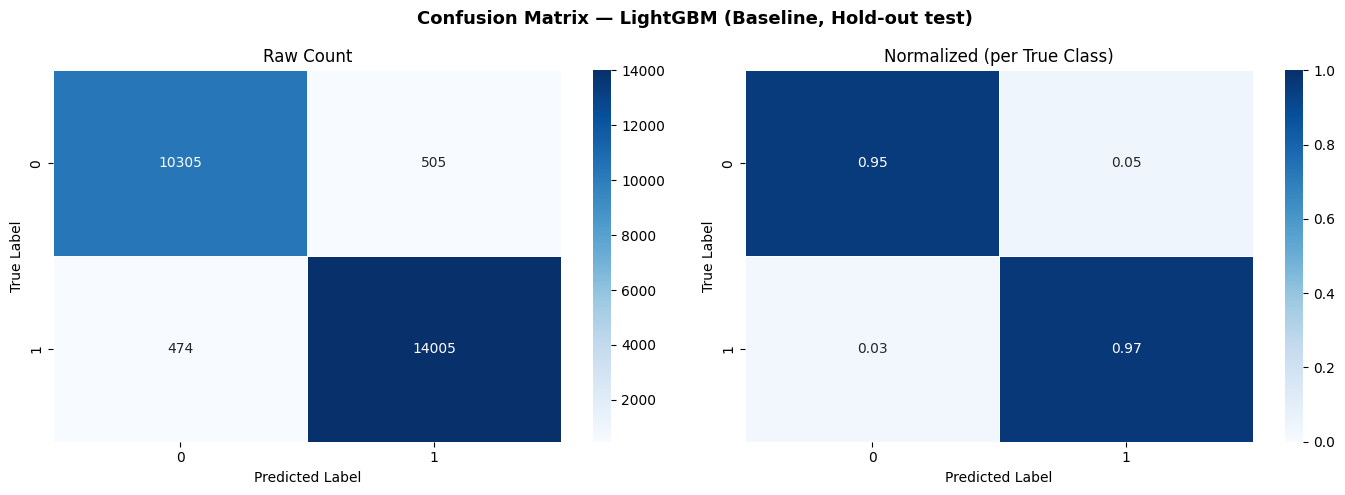

  BASELINE — SKOR PER FOLD, SEMUA MODEL (long-format)
   Group  N Fitur        Model  Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Precision Weighted  Recall Macro  Recall Weighted
Baseline      189 RandomForest     1          20231    0.9630    0.9622       0.9630           0.9623              0.9630        0.9621           0.9630
Baseline      189 RandomForest     2          20231    0.9618    0.9609       0.9618           0.9612              0.9618        0.9607           0.9618
Baseline      189 RandomForest     3          20231    0.9629    0.9621       0.9629           0.9621              0.9629        0.9620           0.9629
Baseline      189 RandomForest     4          20231    0.9629    0.9621       0.9629           0.9621              0.9629        0.9621           0.9629
Baseline      189 RandomForest     5          20230    0.9623    0.9615       0.9623           0.9616              0.9623        0.9614           0.9623
Baseline      189      XGBoo

In [10]:

# %% [markdown]
# ## 4. Baseline — Tanpa Feature Selection, Tanpa Resampling
#
# RandomForest, XGBoost, LightGBM dievaluasi dengan Stratified K-Fold CV
# (skor dicatat per fold), lalu juga dievaluasi di hold-out test set.
 
# %%
baseline_models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=5,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=7, learning_rate=0.2, random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=None, learning_rate=0.2,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
}
 
N_FEATURES_BASELINE = X_train.shape[1]
 
baseline_cv_summary = {}
baseline_holdout = {}
baseline_perfold_records = []
baseline_oof_preds = {}   # disimpan untuk SHAP nanti (model XGBoost full-fit)
baseline_fitted_models = {}
 
for model_name, estimator in baseline_models.items():
    print(f"\n{'='*60}")
    print(f"  Baseline (tanpa FS, tanpa resampling) — {model_name}")
    print(f"{'='*60}")
 
    steps = [("classifier", estimator.__class__(**estimator.get_params()))]
 
    start = time.time()
    y_pred_cv, fold_records = run_manual_cv(
        steps, X_train, y_train, skf,
        group_label='Baseline', n_features=N_FEATURES_BASELINE, model_name=model_name
    )
    cv_time = time.time() - start
    print(f"  CV Time ({N_SPLITS}-fold) : {cv_time:.4f}s")
 
    baseline_perfold_records.extend(fold_records)
    baseline_oof_preds[model_name] = y_pred_cv
 
    # Tampilkan skor tiap fold (bukan cuma rata-rata) untuk model ini
    fold_preview_df = pd.DataFrame(fold_records).round(4)
    print(f"\n  Skor per fold — {model_name} (Baseline):")
    print(fold_preview_df[[
        'Fold', 'N Val Samples', 'Accuracy', 'F1 Macro', 'F1 Weighted',
        'Precision Macro', 'Recall Macro'
    ]].to_string(index=False))
 
    print(f"\n  Classification Report (CV, out-of-fold) — {model_name} (Baseline):")
    print(classification_report(y_train, y_pred_cv,
                                  target_names=[str(c) for c in class_labels], zero_division=0))
    plot_confusion_matrix(y_train, y_pred_cv,
                           f'Confusion Matrix — {model_name} (Baseline, CV out-of-fold)', class_labels)
 
    baseline_cv_summary[model_name] = summarize_cv_report(
        y_train, y_pred_cv, fold_records, 'Baseline', N_FEATURES_BASELINE, model_name, cv_time
    )
 
    # Evaluasi hold-out + simpan model yang di-fit di seluruh X_train
    # (model XGBoost dari sini dipakai untuk SHAP di Bagian 5)
    holdout_result, y_pred_test = evaluate_holdout(
        steps, X_train, y_train, X_test, y_test, 'Baseline', N_FEATURES_BASELINE, model_name
    )
    baseline_holdout[model_name] = holdout_result
 
    fitted_pipeline = Pipeline(steps)
    fitted_pipeline.fit(X_train, y_train)
    baseline_fitted_models[model_name] = fitted_pipeline.named_steps['classifier']
 
    print(f"\n  Classification Report (Hold-out Test) — {model_name} (Baseline):")
    print(classification_report(y_test, y_pred_test,
                                  target_names=[str(c) for c in class_labels], zero_division=0))
    plot_confusion_matrix(y_test, y_pred_test,
                           f'Confusion Matrix — {model_name} (Baseline, Hold-out test)', class_labels)
 
# Model XGBoost baseline (full-fit di X_train) -> dipakai untuk SHAP
xgb_model = baseline_fitted_models['XGBoost']
 
# %%
baseline_perfold_df = pd.DataFrame(baseline_perfold_records).round(4)
baseline_perfold_df = baseline_perfold_df[[
    'Group', 'N Fitur', 'Model', 'Fold', 'N Val Samples',
    'Accuracy', 'F1 Macro', 'F1 Weighted',
    'Precision Macro', 'Precision Weighted', 'Recall Macro', 'Recall Weighted'
]]
 
baseline_cv_summary_df = pd.DataFrame(baseline_cv_summary).T.round(4)
baseline_holdout_df = pd.DataFrame(baseline_holdout).T.round(4)
 
print("="*70)
print("  BASELINE — SKOR PER FOLD, SEMUA MODEL (long-format)")
print("="*70)
print(baseline_perfold_df.to_string(index=False))
 
print("\n" + "="*70)
print("  BASELINE — RATA-RATA CV PER MODEL")
print("="*70)
print(baseline_cv_summary_df.sort_values('F1 Macro', ascending=False).to_string())
 
print("\n" + "="*70)
print("  BASELINE — HOLD-OUT TEST SET PER MODEL")
print("="*70)
print(baseline_holdout_df.sort_values('F1 Macro', ascending=False).to_string())
 

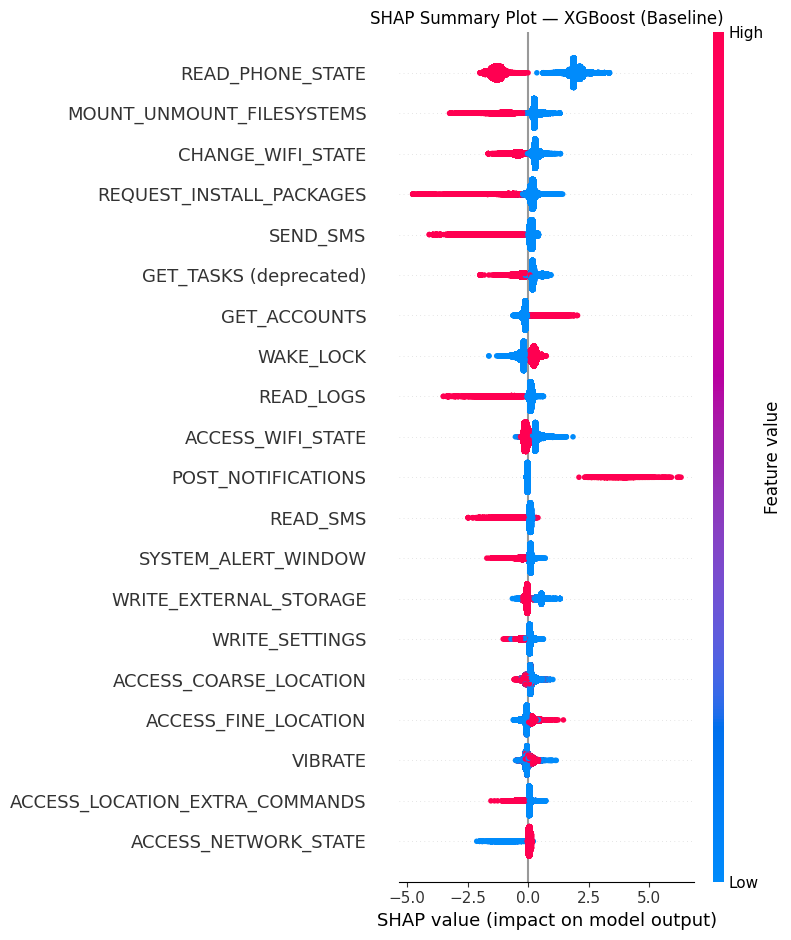

Top 20 Fitur (XGBoost — SHAP):
                       Feature  SHAP_Importance
              READ_PHONE_STATE         1.600112
     MOUNT_UNMOUNT_FILESYSTEMS         0.498613
             CHANGE_WIFI_STATE         0.344110
      REQUEST_INSTALL_PACKAGES         0.305221
                      SEND_SMS         0.298661
        GET_TASKS (deprecated)         0.293301
                  GET_ACCOUNTS         0.270226
                     WAKE_LOCK         0.269143
                     READ_LOGS         0.254429
             ACCESS_WIFI_STATE         0.182161
            POST_NOTIFICATIONS         0.164421
                      READ_SMS         0.161742
           SYSTEM_ALERT_WINDOW         0.155107
        WRITE_EXTERNAL_STORAGE         0.147484
                WRITE_SETTINGS         0.132048
        ACCESS_COARSE_LOCATION         0.123425
          ACCESS_FINE_LOCATION         0.119399
                       VIBRATE         0.110731
ACCESS_LOCATION_EXTRA_COMMANDS         0.105069
         

In [11]:
# %%
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)
 
plt.figure()
shap.summary_plot(shap_values_xgb, X_train, class_names=[str(c) for c in class_labels], show=False)
plt.title("SHAP Summary Plot — XGBoost (Baseline)")
plt.tight_layout()
plt.show()
 
# %%
if shap_values_xgb.ndim == 3:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=(0, 2))
else:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=0)
 
shap_xgb_df = pd.DataFrame({
    'Feature'        : X_train.columns,
    'SHAP_Importance': shap_xgb_mean
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
 
print("Top 20 Fitur (XGBoost — SHAP):")
print(shap_xgb_df.head(20).to_string(index=False))
 


  Persentil P=10% -> 19 fitur

  [XGBoost]
  CV Time (5-fold) : 284.6153s

  Skor per fold — XGBoost, P=10%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9458    0.9447       0.9458           0.9447        0.9446
    2          20231    0.9478    0.9465       0.9477           0.9474        0.9457
    3          20231    0.9498    0.9487       0.9498           0.9486        0.9489
    4          20231    0.9489    0.9479       0.9489           0.9478        0.9479
    5          20230    0.9497    0.9485       0.9496           0.9491        0.9480

  Classification Report (CV, out-of-fold) — XGBoost, P=10%:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     43241
           1       0.95      0.96      0.96     57913

    accuracy                           0.95    101154
   macro avg       0.95      0.95      0.95    101154
weighted avg       0.95      0.95      0.95    

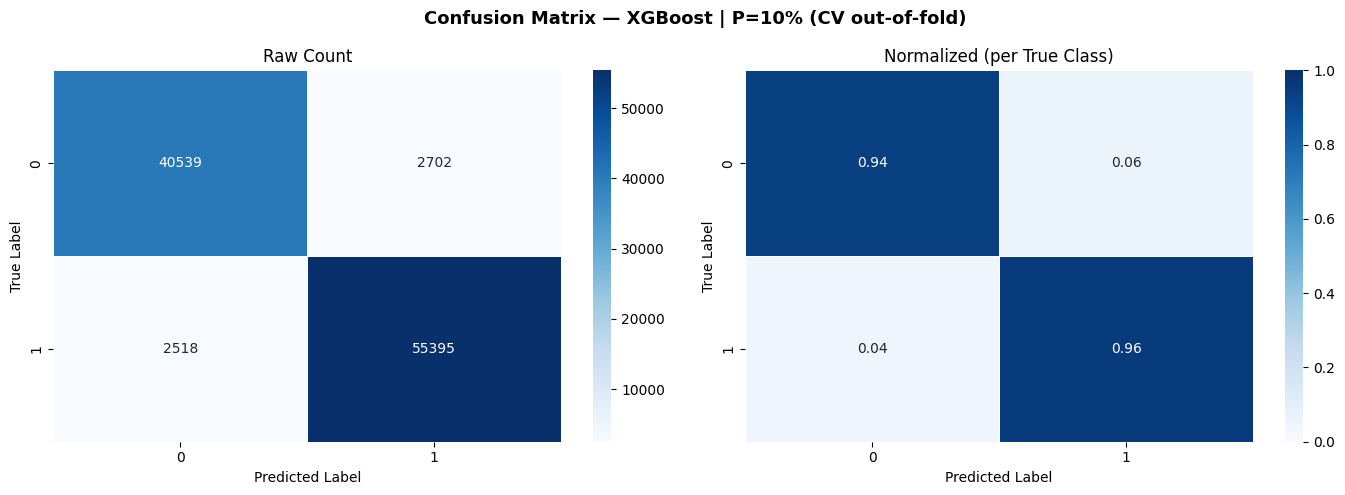


  Classification Report (Hold-out Test) — XGBoost, P=10%:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     10810
           1       0.96      0.96      0.96     14479

    accuracy                           0.95     25289
   macro avg       0.95      0.95      0.95     25289
weighted avg       0.95      0.95      0.95     25289



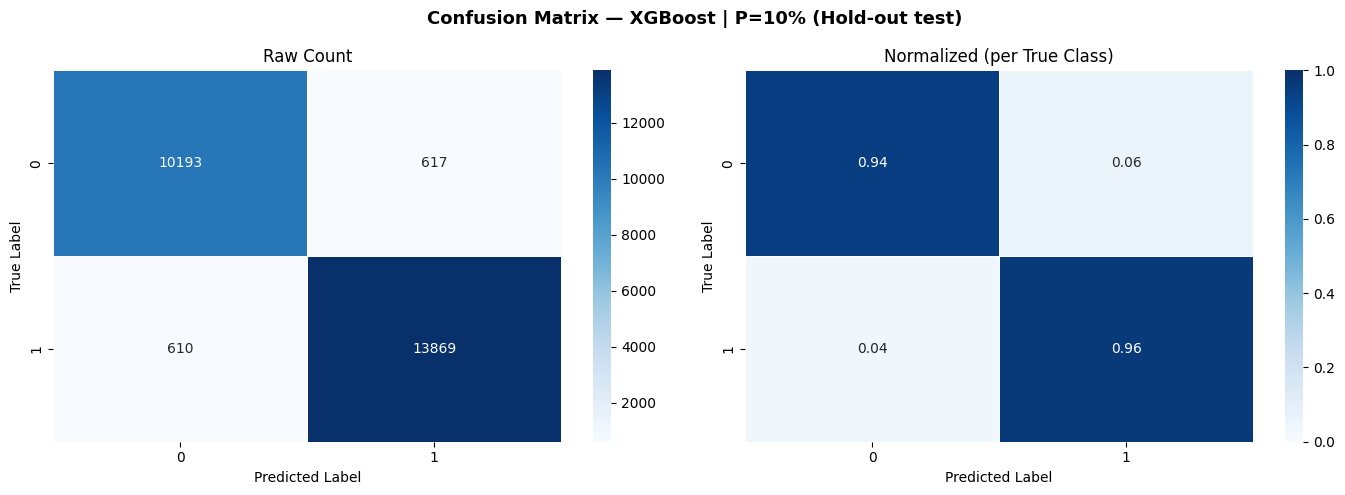


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV Time (5-fold) : 302.0895s

  Skor per fold — LightGBM, P=10%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9464    0.9452       0.9464           0.9453        0.9451
    2          20231    0.9481    0.9469       0.9481           0.9476        0.9462
    3          20231    0.9490    0.9479       0.9490           0.9481        0.9476
    4          20231    0.9491    0.9480       0.9491           0.9479        0.9481
    5          20230    0.9497    0.9485       0.9497           0.9490        0.9481

  Classification Report (CV, out-of-fold) — LightGBM, P=10%:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     43241
           1       0.95      0.96      0.96     57913

    accuracy                           0.95    101154
   macro avg       0.95      0.95      0.95    101154
weighted avg       0.95      0.95      0.95    101154



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


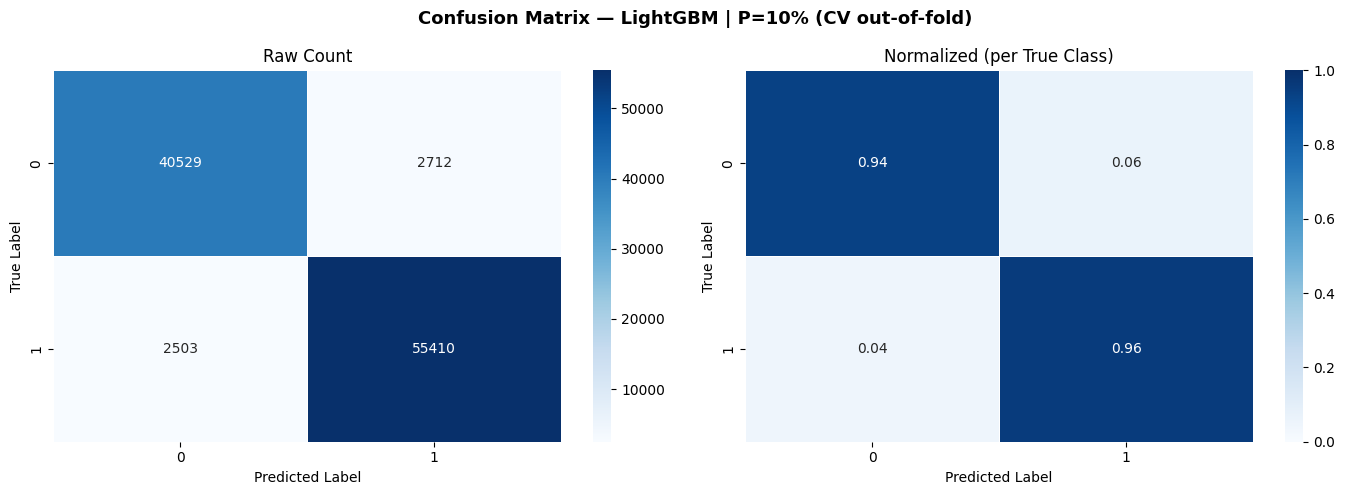


  Classification Report (Hold-out Test) — LightGBM, P=10%:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     10810
           1       0.96      0.96      0.96     14479

    accuracy                           0.95     25289
   macro avg       0.95      0.95      0.95     25289
weighted avg       0.95      0.95      0.95     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


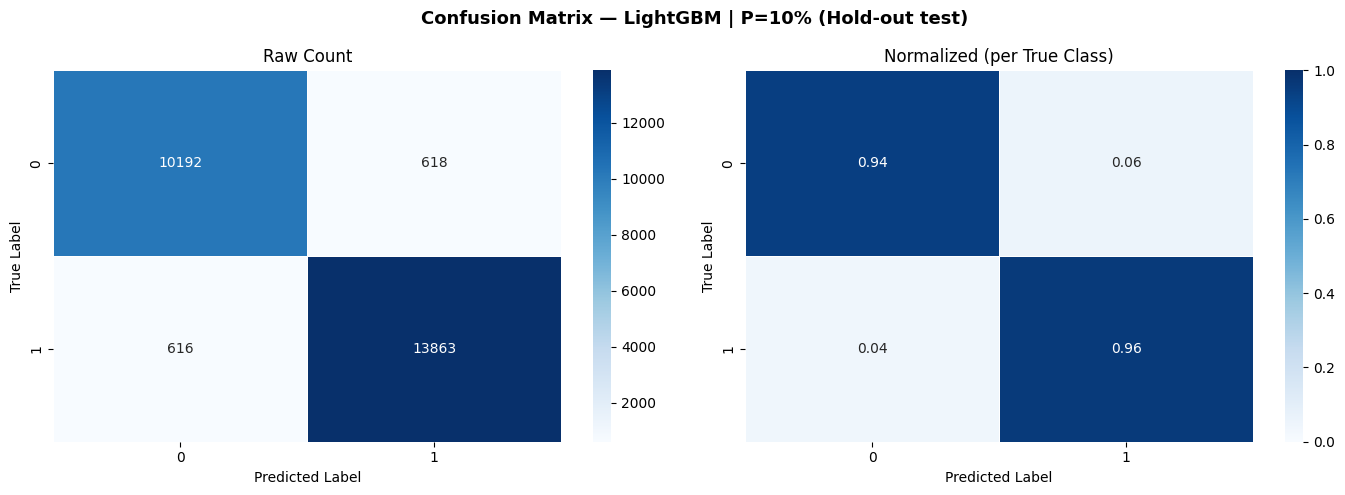


  [RandomForest]
  CV Time (5-fold) : 305.7553s

  Skor per fold — RandomForest, P=10%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9461    0.9450       0.9461           0.9450        0.9449
    2          20231    0.9489    0.9477       0.9489           0.9488        0.9468
    3          20231    0.9492    0.9481       0.9492           0.9482        0.9480
    4          20231    0.9498    0.9487       0.9498           0.9486        0.9489
    5          20230    0.9499    0.9488       0.9499           0.9492        0.9484

  Classification Report (CV, out-of-fold) — RandomForest, P=10%:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     43241
           1       0.95      0.96      0.96     57913

    accuracy                           0.95    101154
   macro avg       0.95      0.95      0.95    101154
weighted avg       0.95      0.95      0.95    101154



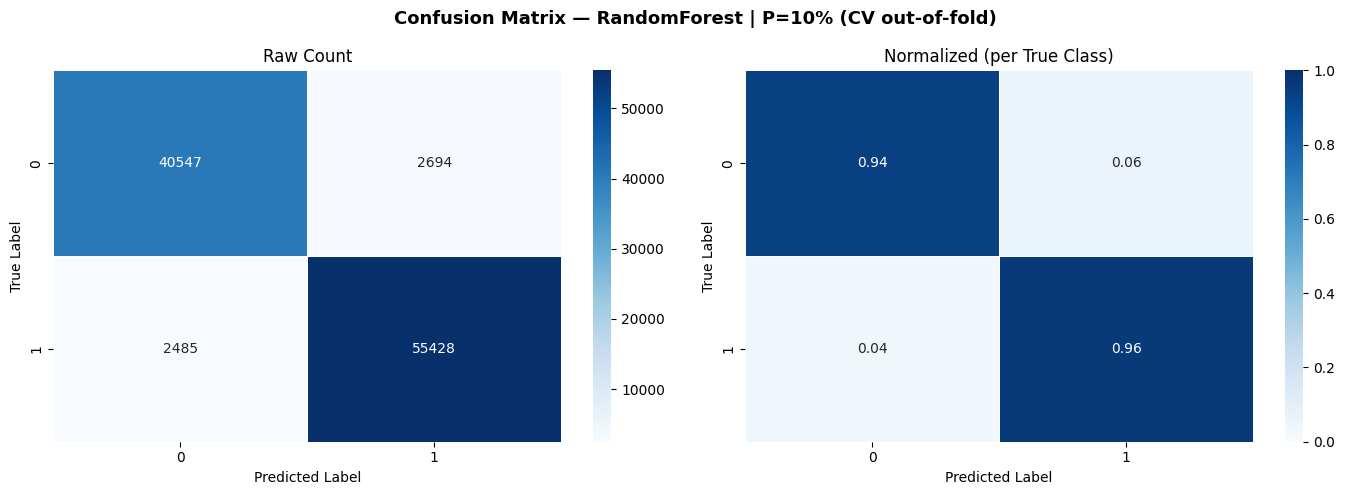


  Classification Report (Hold-out Test) — RandomForest, P=10%:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     10810
           1       0.96      0.96      0.96     14479

    accuracy                           0.95     25289
   macro avg       0.95      0.95      0.95     25289
weighted avg       0.95      0.95      0.95     25289



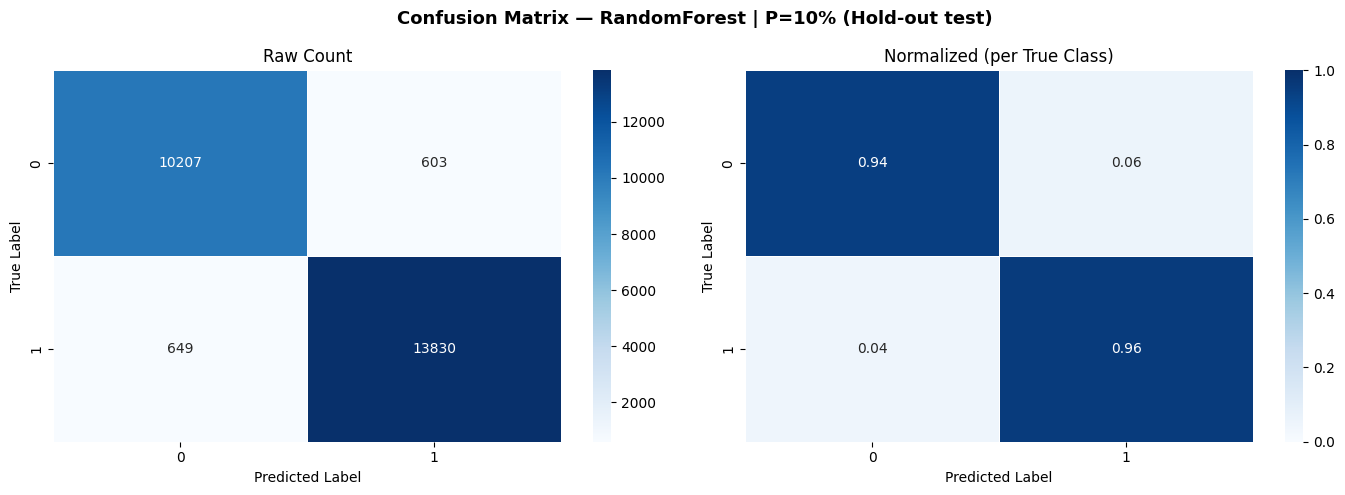


  Persentil P=20% -> 38 fitur

  [XGBoost]
  CV Time (5-fold) : 310.4458s

  Skor per fold — XGBoost, P=20%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9561    0.9551       0.9560           0.9556        0.9546
    2          20231    0.9579    0.9569       0.9578           0.9577        0.9561
    3          20231    0.9589    0.9580       0.9589           0.9582        0.9577
    4          20231    0.9577    0.9568       0.9577           0.9569        0.9566
    5          20230    0.9587    0.9578       0.9587           0.9581        0.9575

  Classification Report (CV, out-of-fold) — XGBoost, P=20%:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     43241
           1       0.96      0.97      0.96     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    

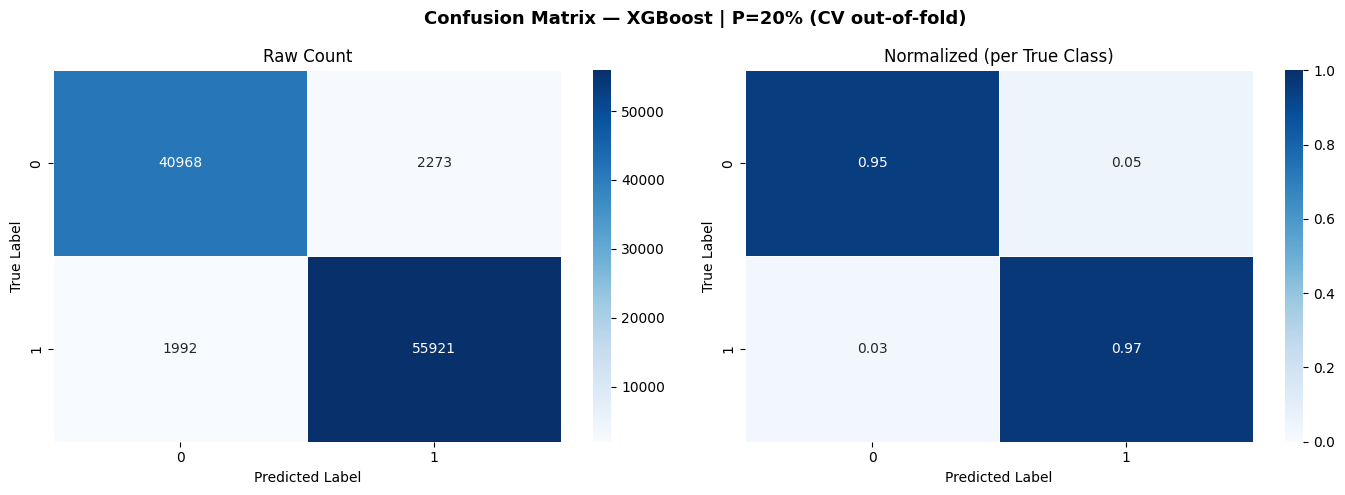


  Classification Report (Hold-out Test) — XGBoost, P=20%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     10810
           1       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



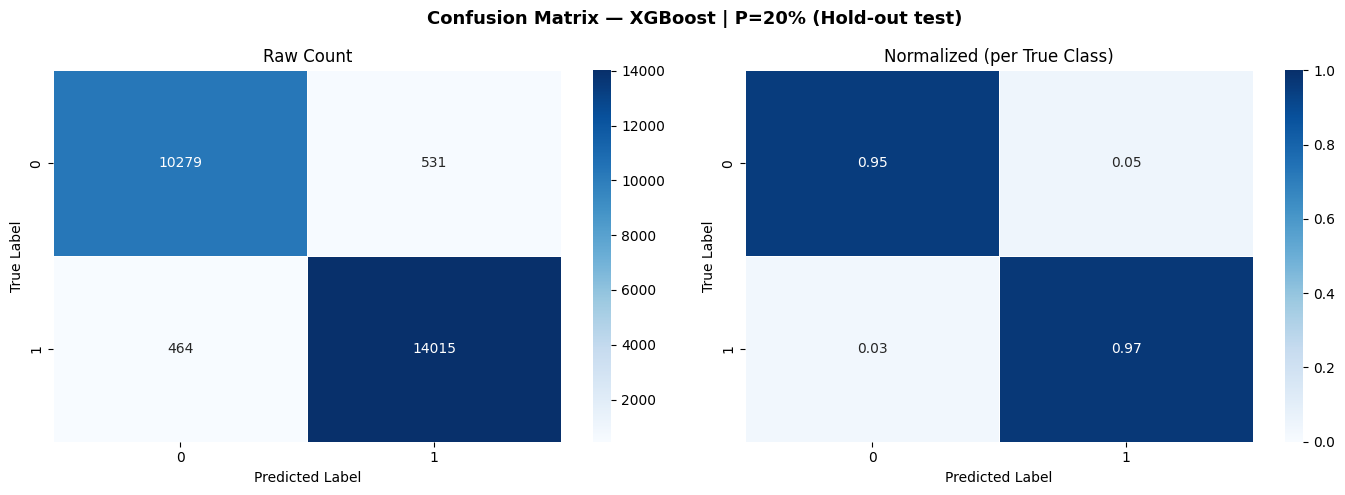


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV Time (5-fold) : 288.6458s

  Skor per fold — LightGBM, P=20%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9549    0.9539       0.9549           0.9542        0.9536
    2          20231    0.9570    0.9560       0.9570           0.9569        0.9552
    3          20231    0.9581    0.9572       0.9581           0.9575        0.9568
    4          20231    0.9569    0.9560       0.9569           0.9560        0.9560
    5          20230    0.9573    0.9564       0.9573           0.9566        0.9562

  Classification Report (CV, out-of-fold) — LightGBM, P=20%:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     43241
           1       0.96      0.96      0.96     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


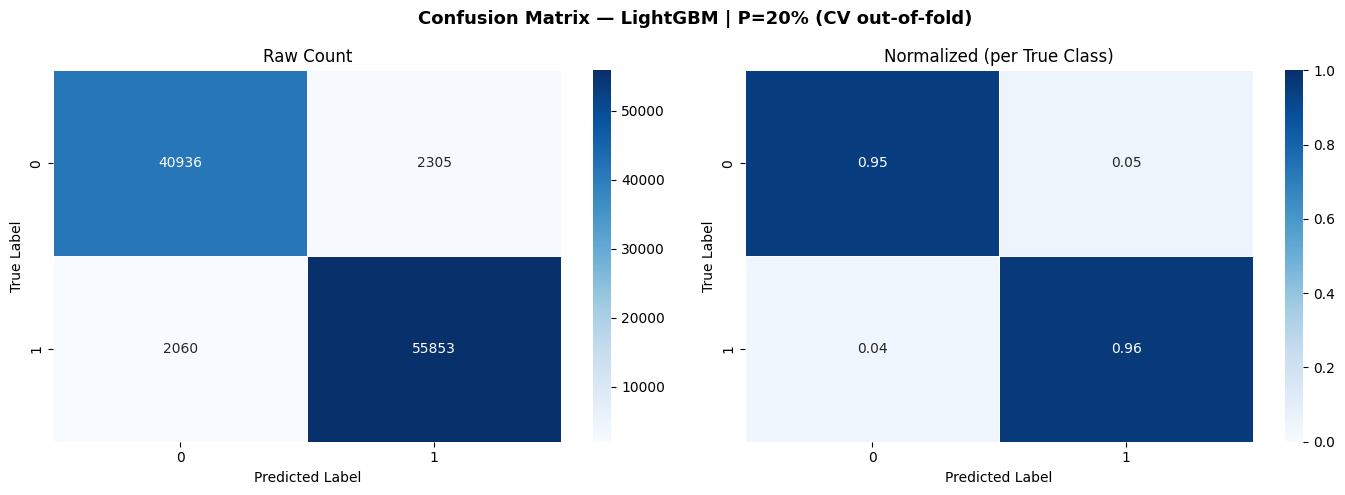


  Classification Report (Hold-out Test) — LightGBM, P=20%:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10810
           1       0.96      0.96      0.96     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


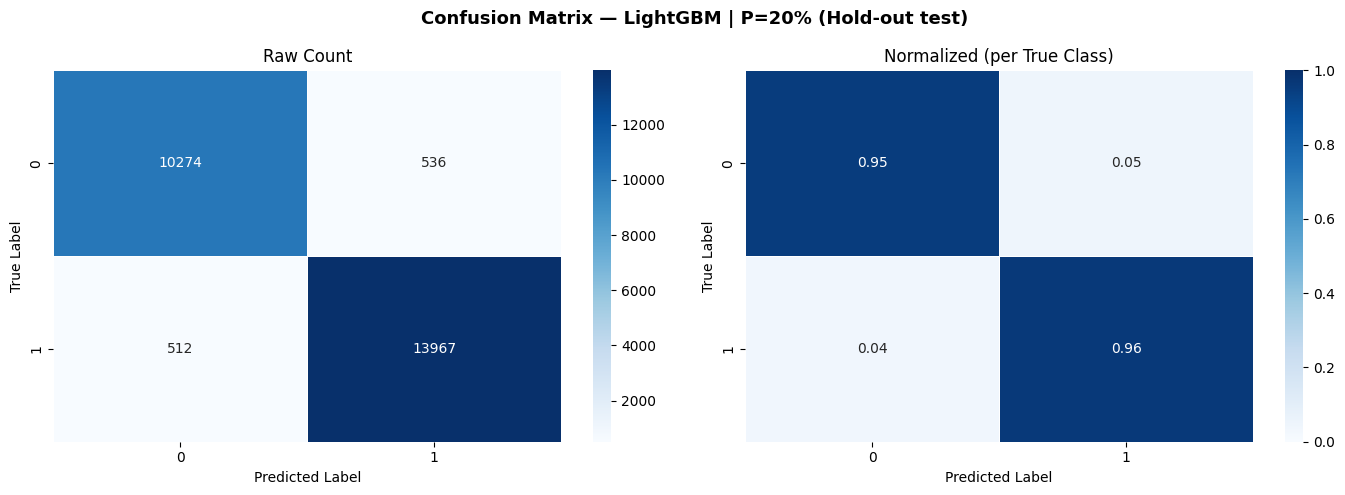


  [RandomForest]
  CV Time (5-fold) : 303.7267s

  Skor per fold — RandomForest, P=20%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9576    0.9567       0.9576           0.9568        0.9565
    2          20231    0.9591    0.9582       0.9591           0.9586        0.9578
    3          20231    0.9584    0.9575       0.9584           0.9575        0.9575
    4          20231    0.9596    0.9588       0.9596           0.9586        0.9590
    5          20230    0.9592    0.9583       0.9592           0.9584        0.9583

  Classification Report (CV, out-of-fold) — RandomForest, P=20%:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     43241
           1       0.96      0.96      0.96     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



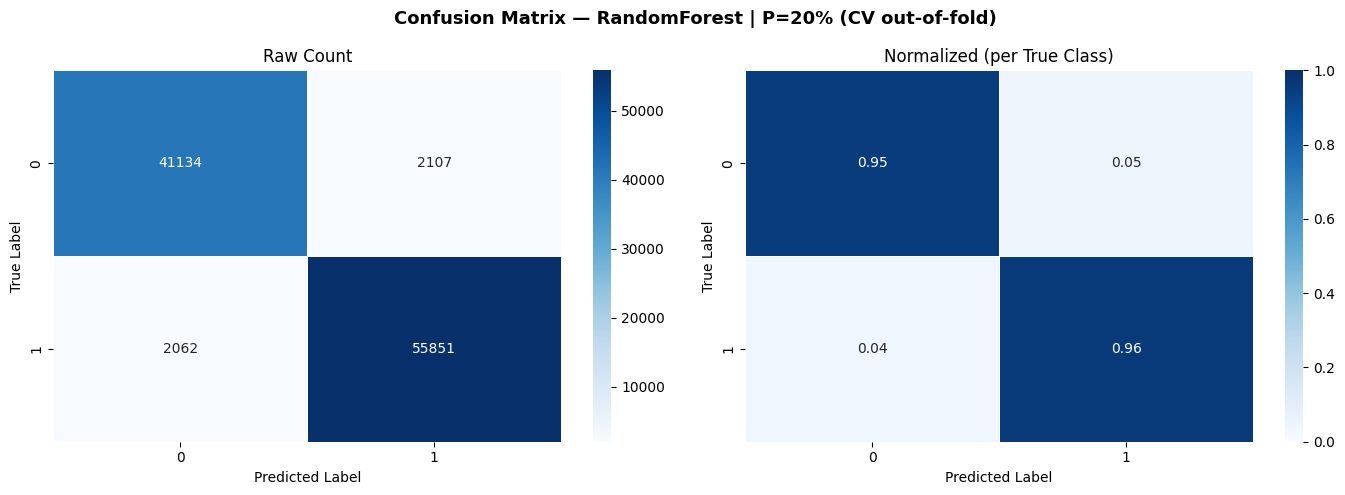


  Classification Report (Hold-out Test) — RandomForest, P=20%:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



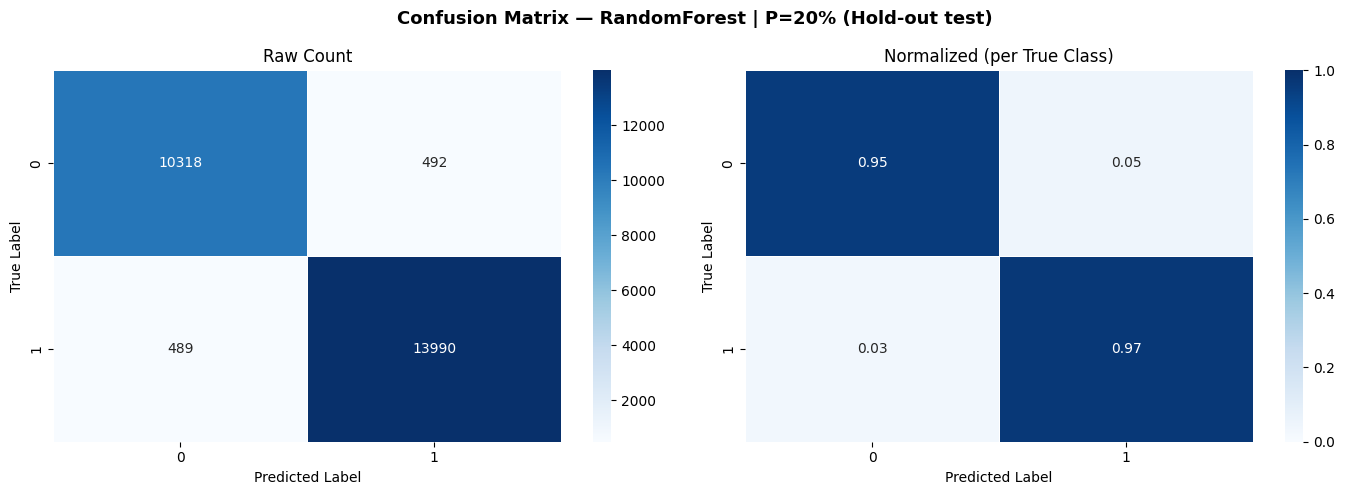


  Persentil P=30% -> 57 fitur

  [XGBoost]
  CV Time (5-fold) : 271.7123s

  Skor per fold — XGBoost, P=30%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9593    0.9583       0.9592           0.9589        0.9578
    2          20231    0.9584    0.9574       0.9583           0.9583        0.9566
    3          20231    0.9592    0.9583       0.9592           0.9586        0.9579
    4          20231    0.9583    0.9574       0.9583           0.9575        0.9572
    5          20230    0.9592    0.9583       0.9592           0.9587        0.9579

  Classification Report (CV, out-of-fold) — XGBoost, P=30%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.96     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    

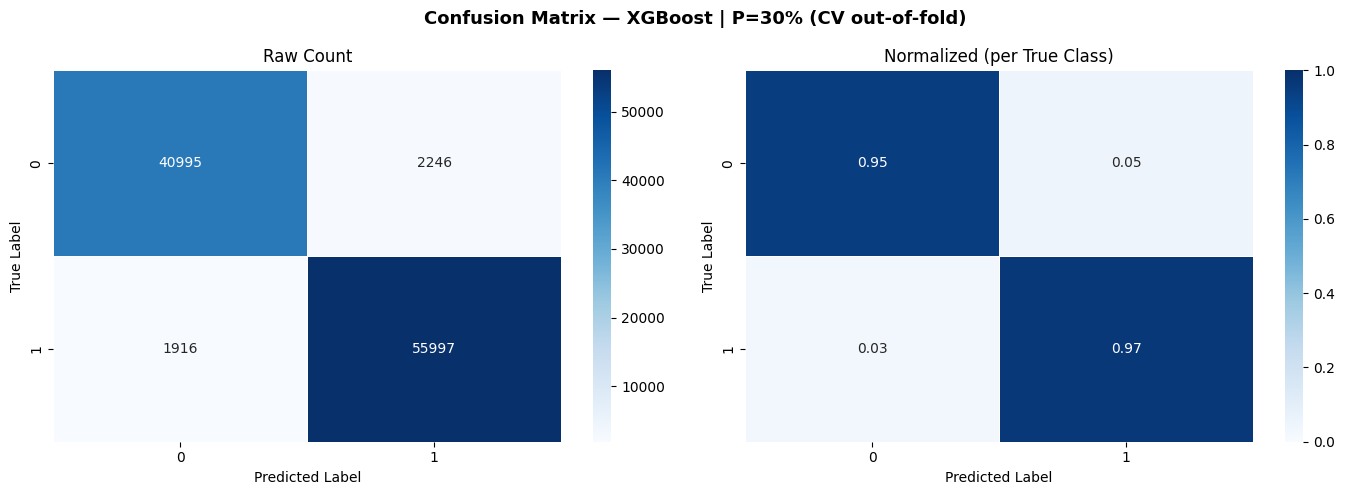


  Classification Report (Hold-out Test) — XGBoost, P=30%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



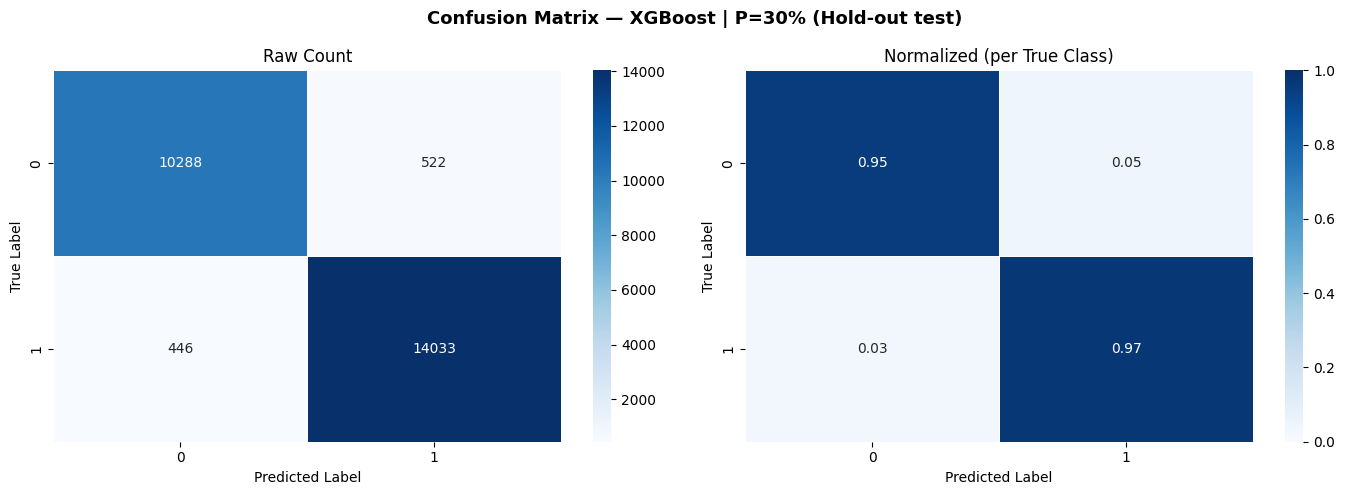


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV Time (5-fold) : 279.2010s

  Skor per fold — LightGBM, P=30%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9576    0.9566       0.9576           0.9571        0.9562
    2          20231    0.9594    0.9585       0.9594           0.9592        0.9578
    3          20231    0.9594    0.9585       0.9594           0.9587        0.9582
    4          20231    0.9589    0.9580       0.9589           0.9580        0.9580
    5          20230    0.9589    0.9580       0.9589           0.9583        0.9576

  Classification Report (CV, out-of-fold) — LightGBM, P=30%:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     43241
           1       0.96      0.97      0.96     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


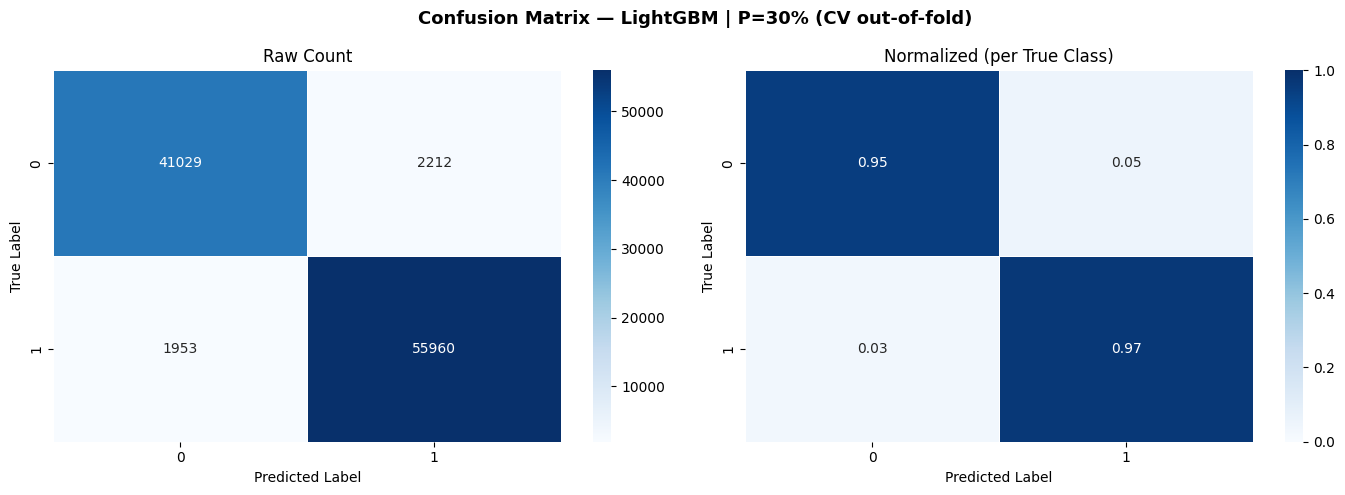


  Classification Report (Hold-out Test) — LightGBM, P=30%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     10810
           1       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


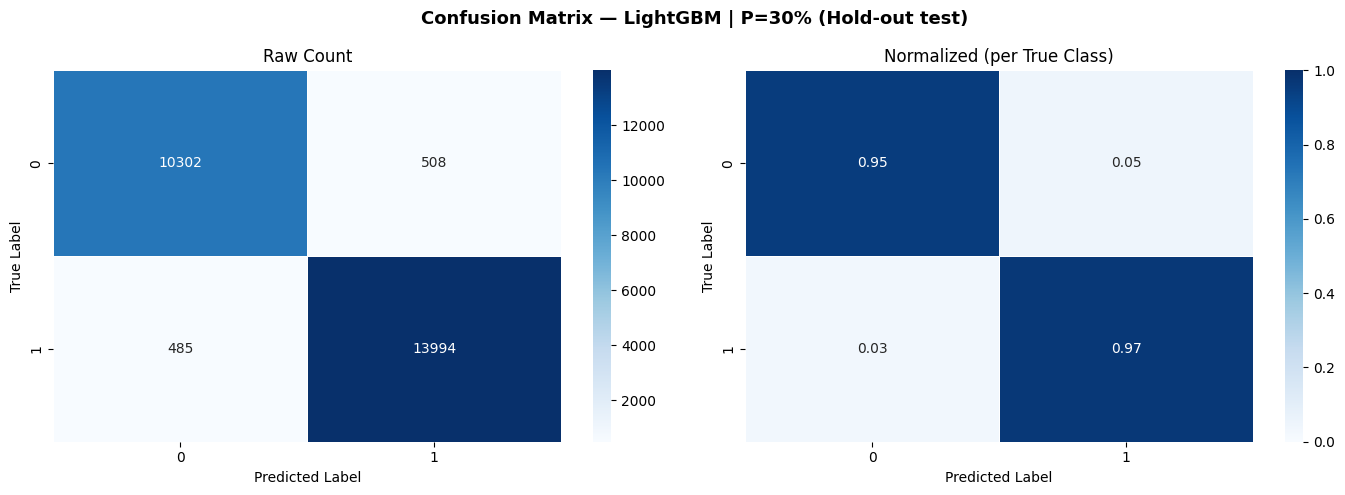


  [RandomForest]
  CV Time (5-fold) : 311.1255s

  Skor per fold — RandomForest, P=30%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9596    0.9587       0.9596           0.9588        0.9587
    2          20231    0.9597    0.9588       0.9597           0.9591        0.9586
    3          20231    0.9604    0.9595       0.9604           0.9594        0.9597
    4          20231    0.9607    0.9599       0.9607           0.9596        0.9602
    5          20230    0.9606    0.9597       0.9605           0.9598        0.9596

  Classification Report (CV, out-of-fold) — RandomForest, P=30%:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     43241
           1       0.97      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



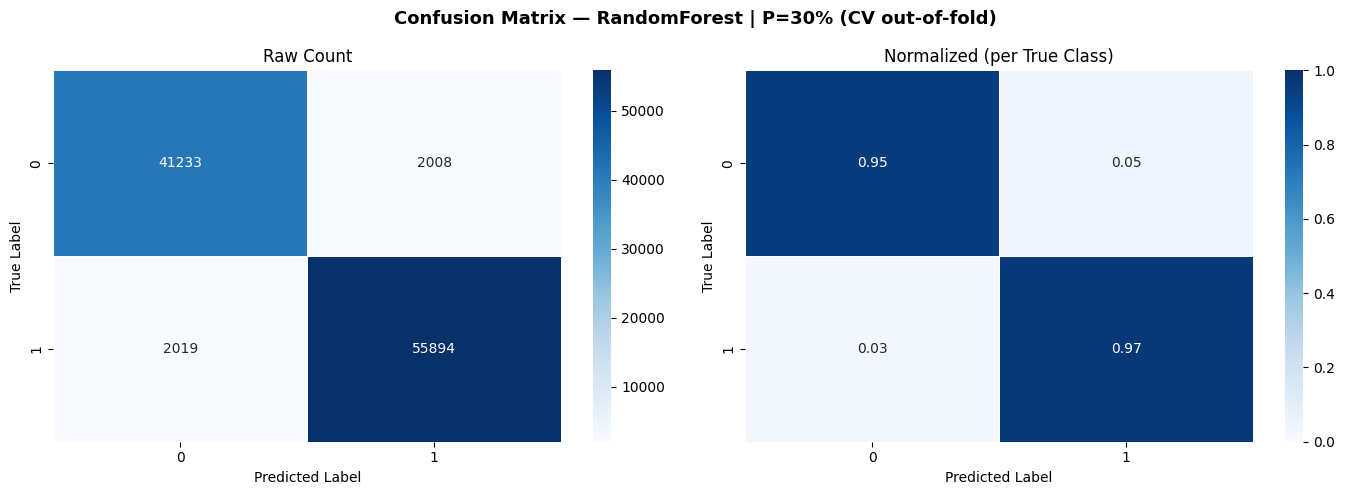


  Classification Report (Hold-out Test) — RandomForest, P=30%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



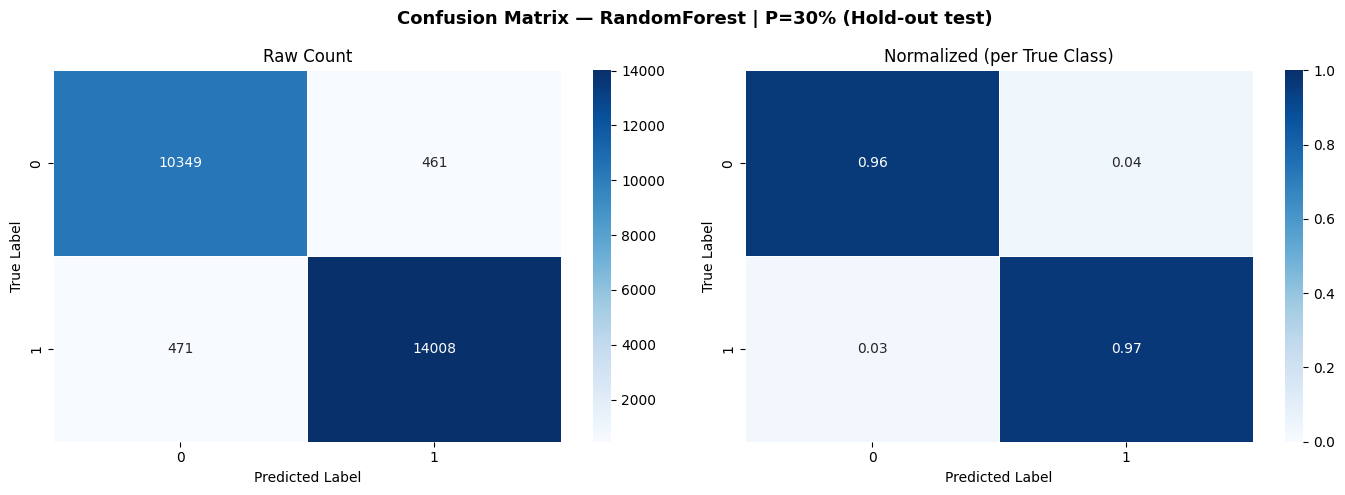


  Persentil P=40% -> 76 fitur

  [XGBoost]
  CV Time (5-fold) : 285.0982s

  Skor per fold — XGBoost, P=40%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9606    0.9597       0.9606           0.9604        0.9591
    2          20231    0.9596    0.9586       0.9595           0.9595        0.9578
    3          20231    0.9610    0.9601       0.9610           0.9605        0.9598
    4          20231    0.9599    0.9590       0.9599           0.9593        0.9588
    5          20230    0.9606    0.9597       0.9605           0.9602        0.9591

  Classification Report (CV, out-of-fold) — XGBoost, P=40%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    

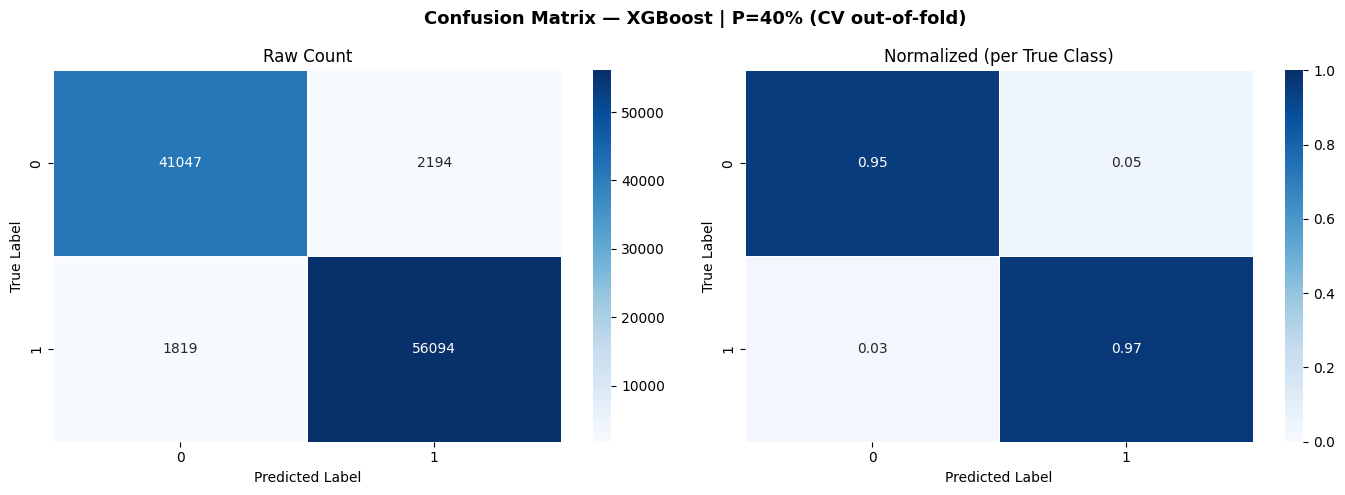


  Classification Report (Hold-out Test) — XGBoost, P=40%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



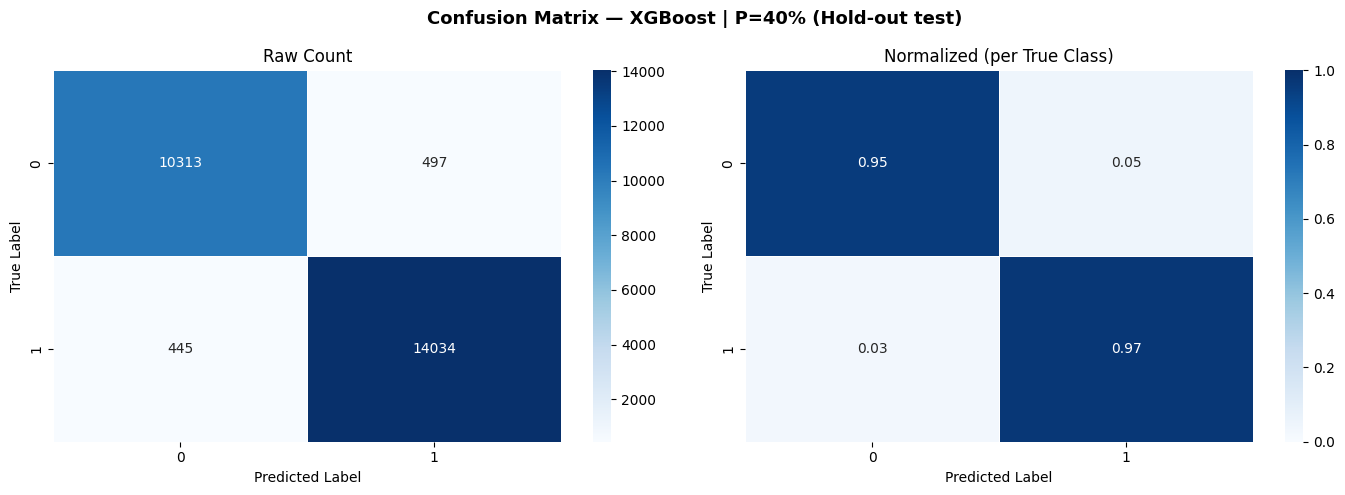


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJar

  CV Time (5-fold) : 290.9607s

  Skor per fold — LightGBM, P=40%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9584    0.9575       0.9584           0.9579        0.9571
    2          20231    0.9600    0.9590       0.9599           0.9599        0.9582
    3          20231    0.9600    0.9591       0.9600           0.9594        0.9589
    4          20231    0.9589    0.9580       0.9589           0.9586        0.9574
    5          20230    0.9605    0.9596       0.9605           0.9601        0.9592

  Classification Report (CV, out-of-fold) — LightGBM, P=40%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.96     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



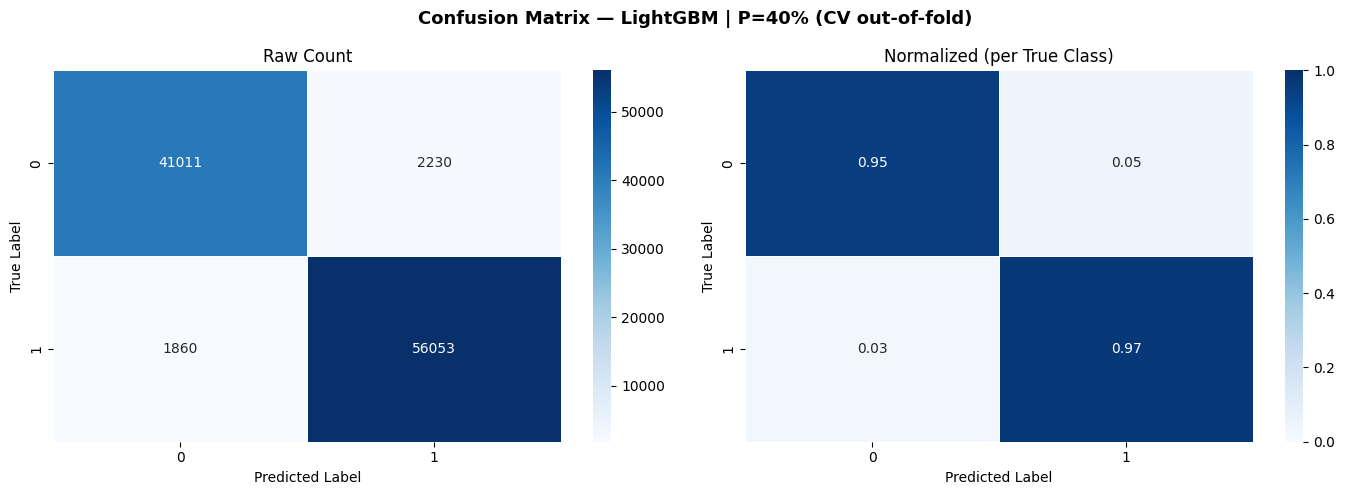


  Classification Report (Hold-out Test) — LightGBM, P=40%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


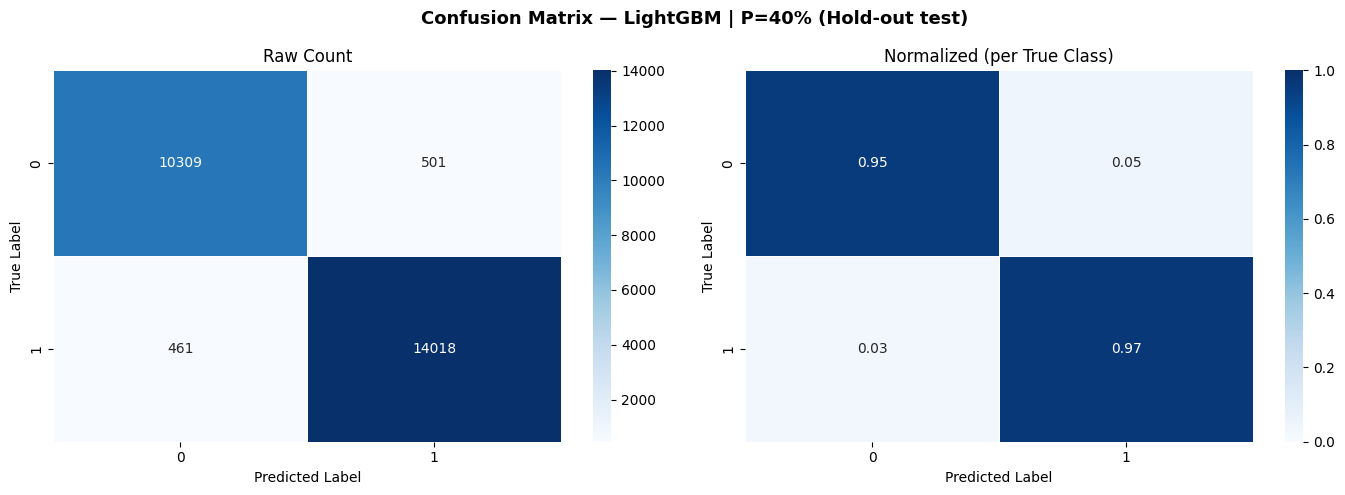


  [RandomForest]
  CV Time (5-fold) : 331.6099s

  Skor per fold — RandomForest, P=40%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9614    0.9606       0.9614           0.9606        0.9607
    2          20231    0.9611    0.9602       0.9611           0.9605        0.9599
    3          20231    0.9618    0.9610       0.9618           0.9610        0.9611
    4          20231    0.9625    0.9617       0.9625           0.9616        0.9619
    5          20230    0.9618    0.9610       0.9618           0.9611        0.9609

  Classification Report (CV, out-of-fold) — RandomForest, P=40%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     43241
           1       0.97      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



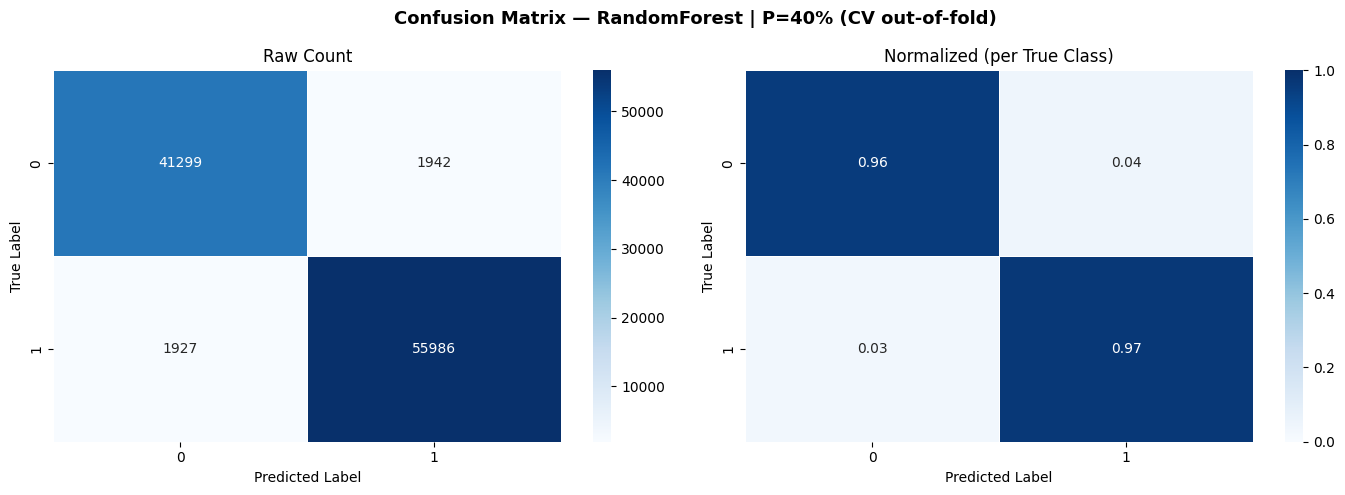


  Classification Report (Hold-out Test) — RandomForest, P=40%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.97     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.97      0.97      0.97     25289



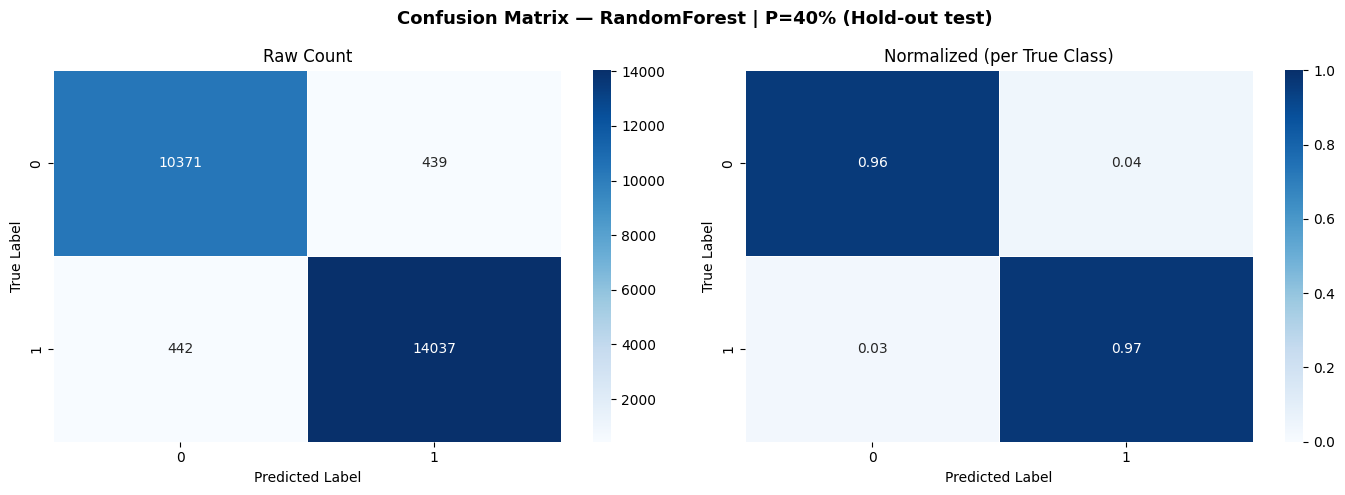


  Persentil P=50% -> 95 fitur

  [XGBoost]
  CV Time (5-fold) : 279.1530s

  Skor per fold — XGBoost, P=50%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9605    0.9595       0.9604           0.9603        0.9589
    2          20231    0.9597    0.9588       0.9597           0.9596        0.9580
    3          20231    0.9614    0.9606       0.9614           0.9609        0.9603
    4          20231    0.9605    0.9596       0.9605           0.9600        0.9593
    5          20230    0.9610    0.9601       0.9610           0.9606        0.9596

  Classification Report (CV, out-of-fold) — XGBoost, P=50%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    

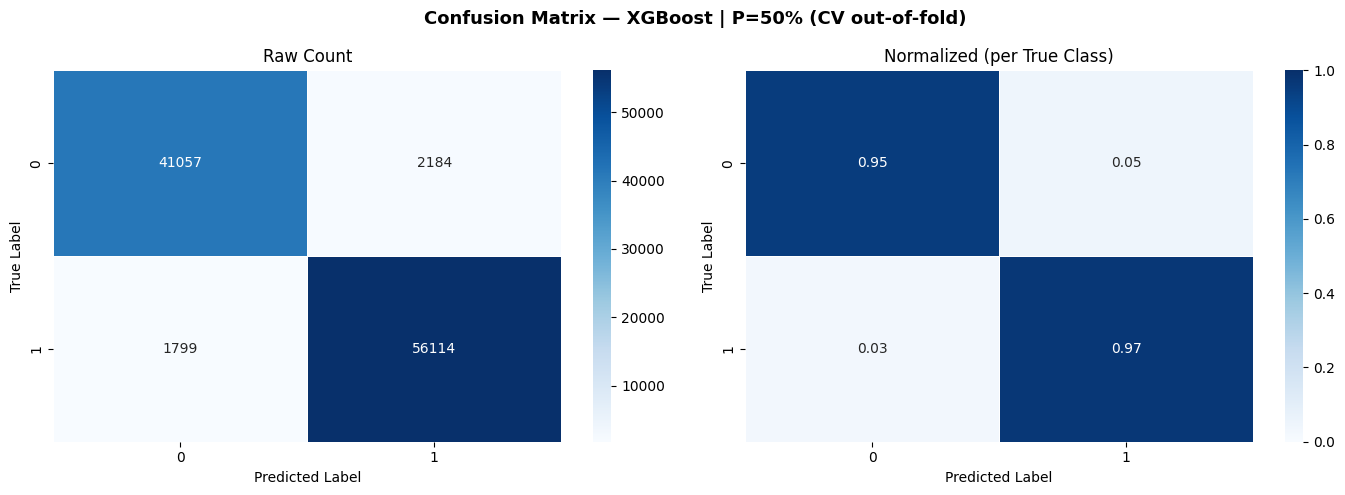


  Classification Report (Hold-out Test) — XGBoost, P=50%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



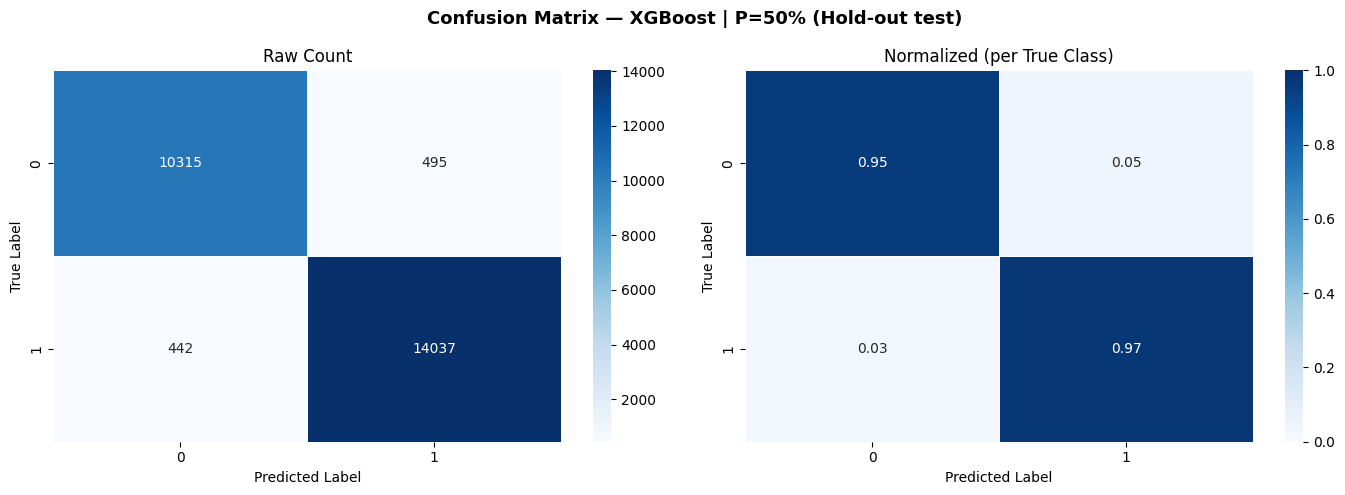


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJar

  CV Time (5-fold) : 281.7472s

  Skor per fold — LightGBM, P=50%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9592    0.9582       0.9591           0.9589        0.9577
    2          20231    0.9593    0.9583       0.9592           0.9595        0.9572
    3          20231    0.9601    0.9592       0.9601           0.9597        0.9587
    4          20231    0.9591    0.9582       0.9591           0.9585        0.9579
    5          20230    0.9602    0.9593       0.9602           0.9599        0.9587

  Classification Report (CV, out-of-fold) — LightGBM, P=50%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.96     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



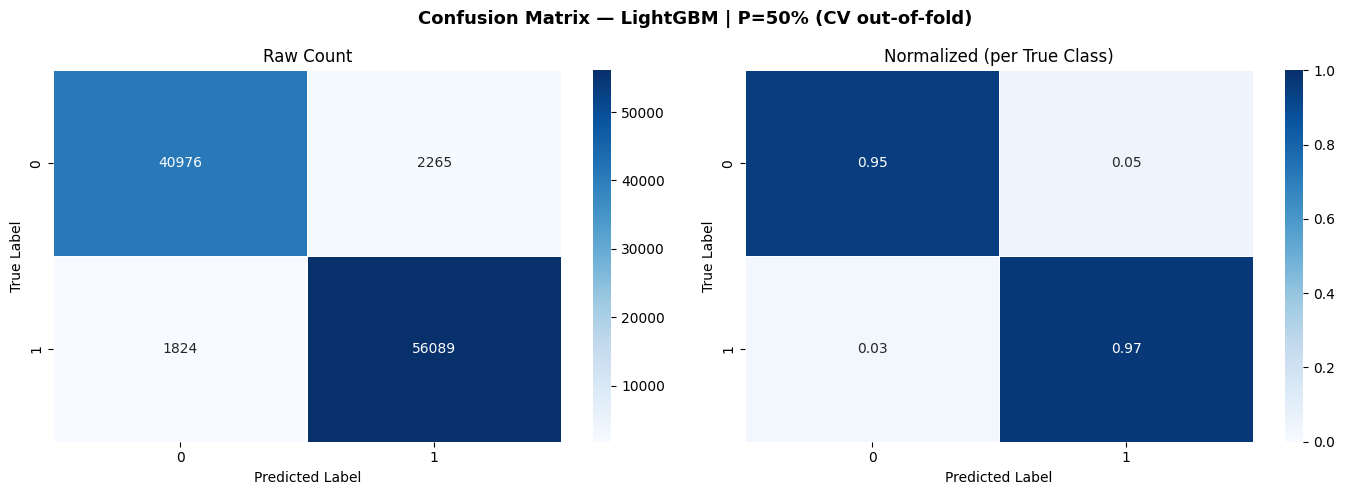


  Classification Report (Hold-out Test) — LightGBM, P=50%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


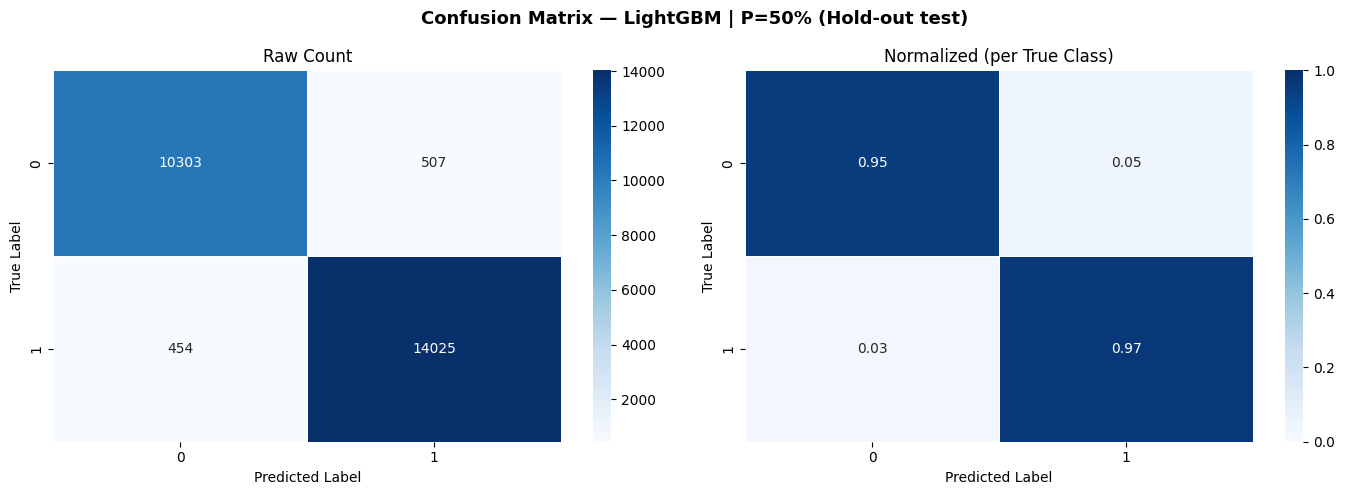


  [RandomForest]
  CV Time (5-fold) : 346.4583s

  Skor per fold — RandomForest, P=50%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9620    0.9612       0.9620           0.9613        0.9611
    2          20231    0.9616    0.9607       0.9616           0.9610        0.9605
    3          20231    0.9623    0.9615       0.9623           0.9615        0.9615
    4          20231    0.9623    0.9616       0.9623           0.9613        0.9618
    5          20230    0.9622    0.9614       0.9622           0.9614        0.9614

  Classification Report (CV, out-of-fold) — RandomForest, P=50%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     43241
           1       0.97      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



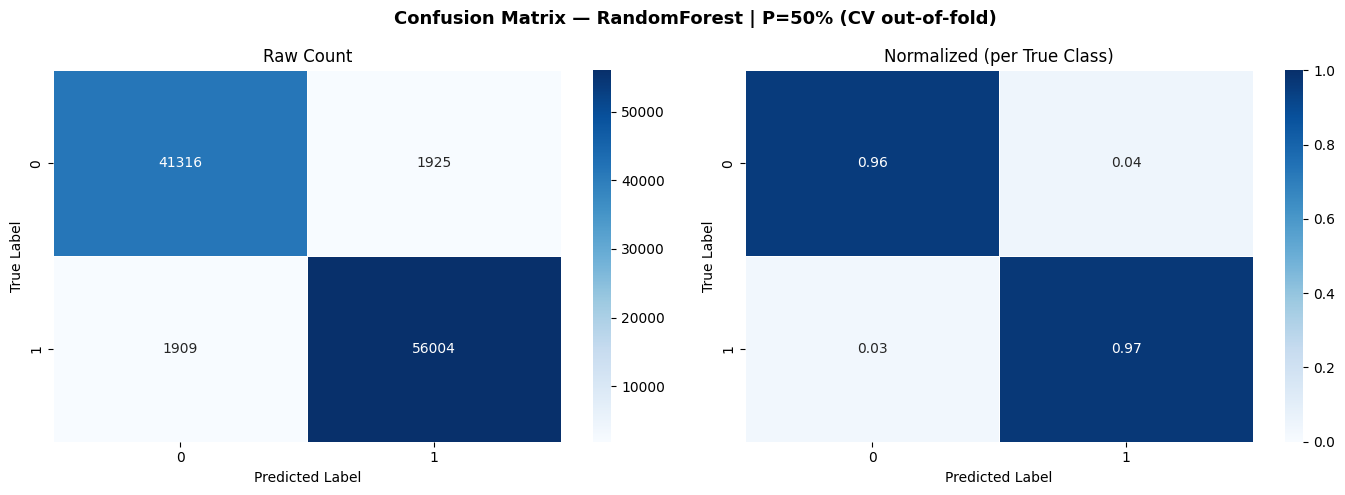


  Classification Report (Hold-out Test) — RandomForest, P=50%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



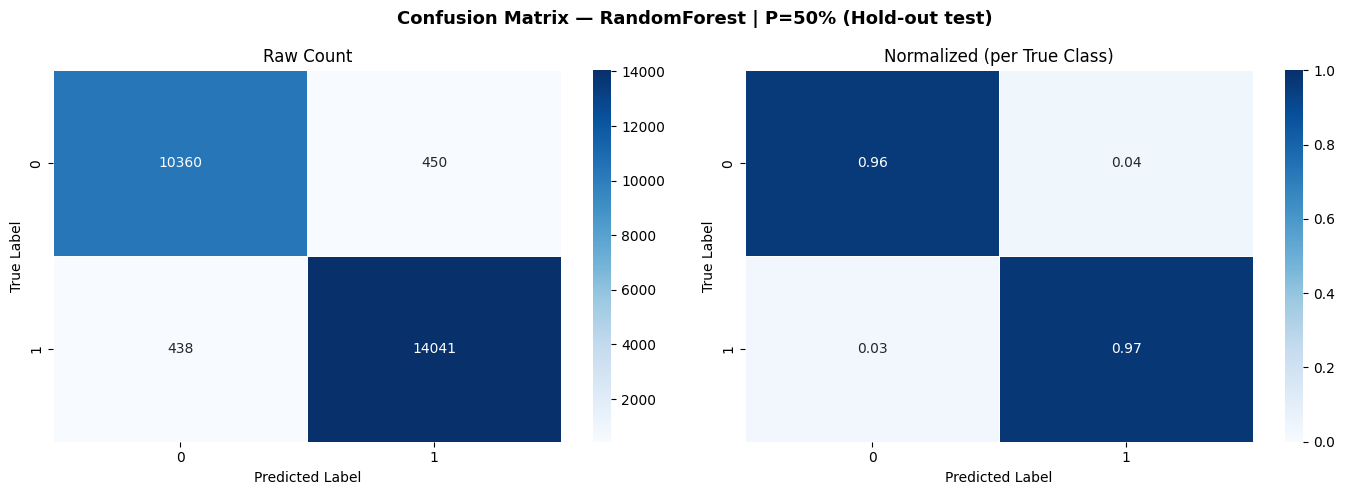


  Persentil P=60% -> 114 fitur

  [XGBoost]
  CV Time (5-fold) : 286.5758s

  Skor per fold — XGBoost, P=60%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9604    0.9595       0.9604           0.9602        0.9589
    2          20231    0.9595    0.9585       0.9594           0.9595        0.9576
    3          20231    0.9609    0.9600       0.9608           0.9605        0.9595
    4          20231    0.9610    0.9601       0.9609           0.9606        0.9595
    5          20230    0.9606    0.9597       0.9605           0.9602        0.9592

  Classification Report (CV, out-of-fold) — XGBoost, P=60%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96   

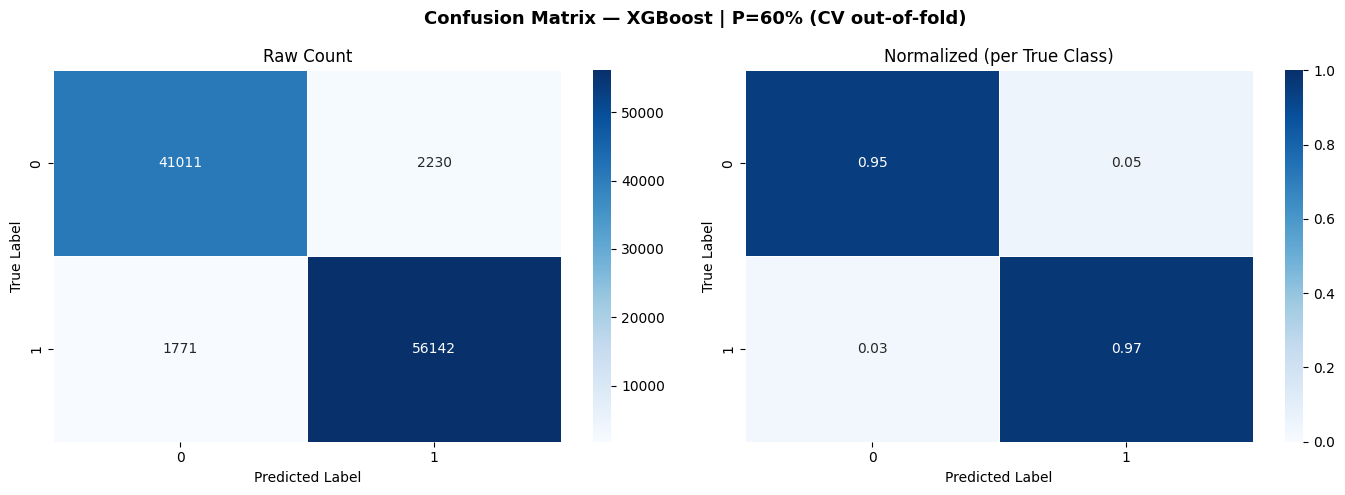


  Classification Report (Hold-out Test) — XGBoost, P=60%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



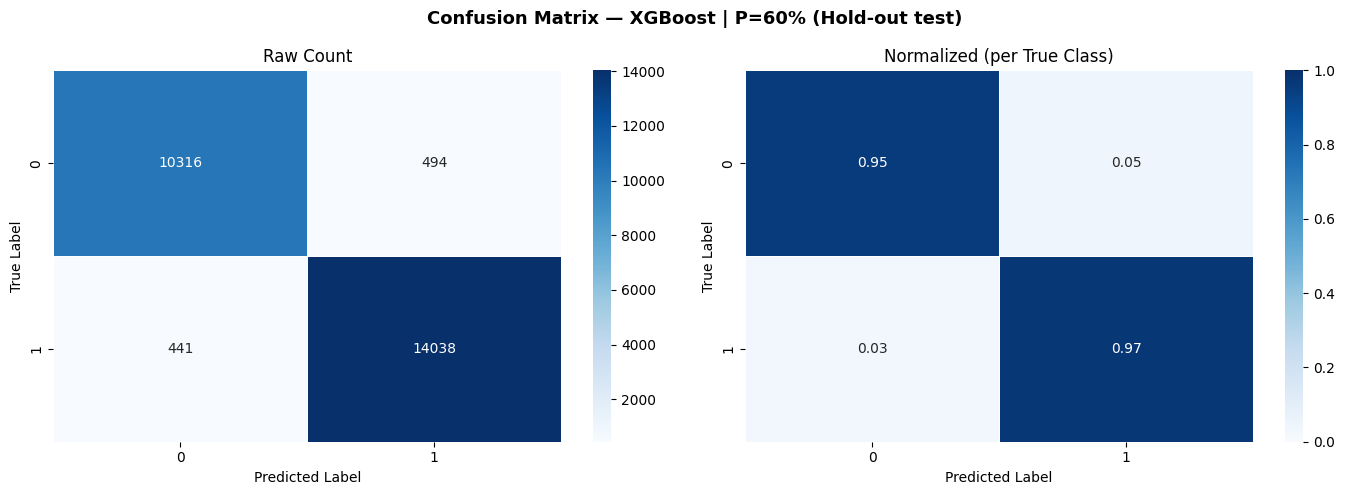


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJar

  CV Time (5-fold) : 287.8048s

  Skor per fold — LightGBM, P=60%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9592    0.9583       0.9592           0.9589        0.9577
    2          20231    0.9588    0.9579       0.9588           0.9587        0.9571
    3          20231    0.9611    0.9603       0.9611           0.9607        0.9599
    4          20231    0.9590    0.9581       0.9590           0.9583        0.9579
    5          20230    0.9619    0.9611       0.9619           0.9616        0.9606

  Classification Report (CV, out-of-fold) — LightGBM, P=60%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



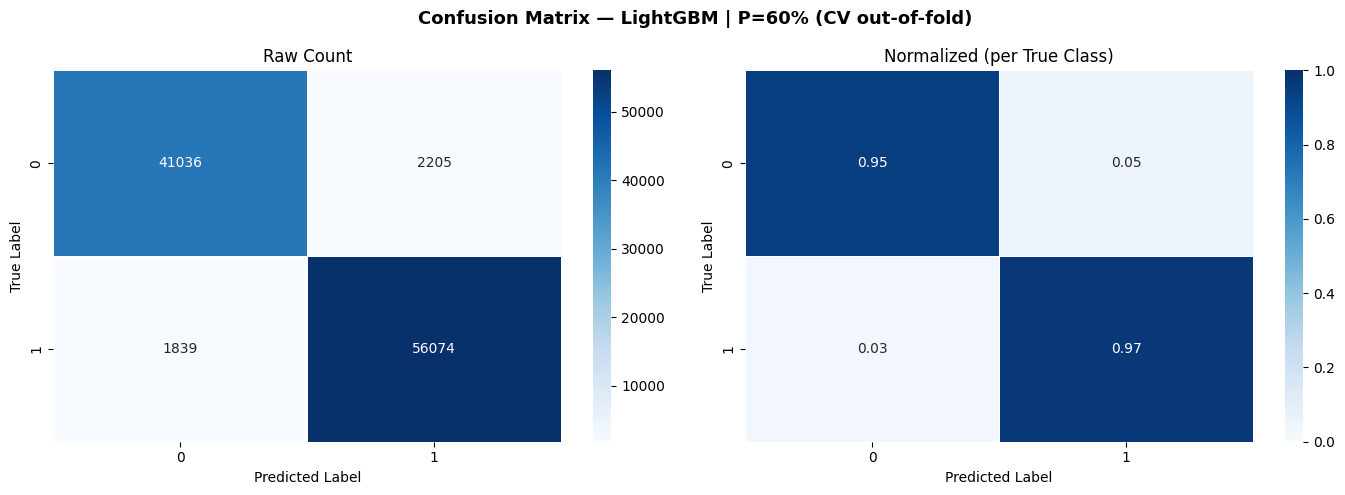


  Classification Report (Hold-out Test) — LightGBM, P=60%:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


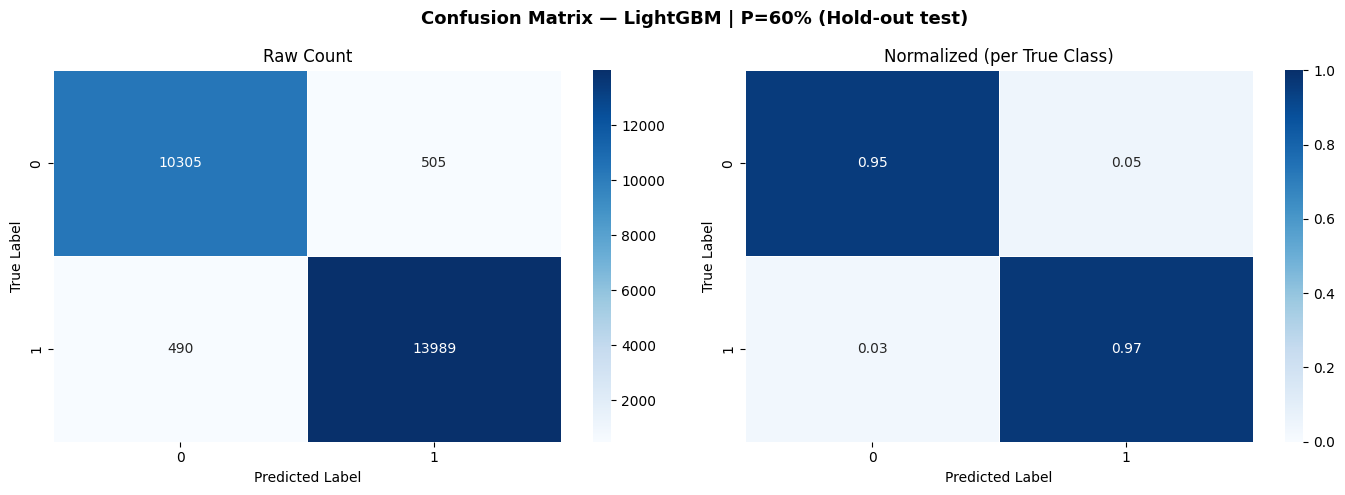


  [RandomForest]
  CV Time (5-fold) : 415.2017s

  Skor per fold — RandomForest, P=60%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9613    0.9605       0.9613           0.9606        0.9604
    2          20231    0.9609    0.9600       0.9609           0.9603        0.9598
    3          20231    0.9624    0.9616       0.9624           0.9616        0.9617
    4          20231    0.9629    0.9621       0.9629           0.9619        0.9623
    5          20230    0.9621    0.9613       0.9621           0.9613        0.9614

  Classification Report (CV, out-of-fold) — RandomForest, P=60%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     43241
           1       0.97      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



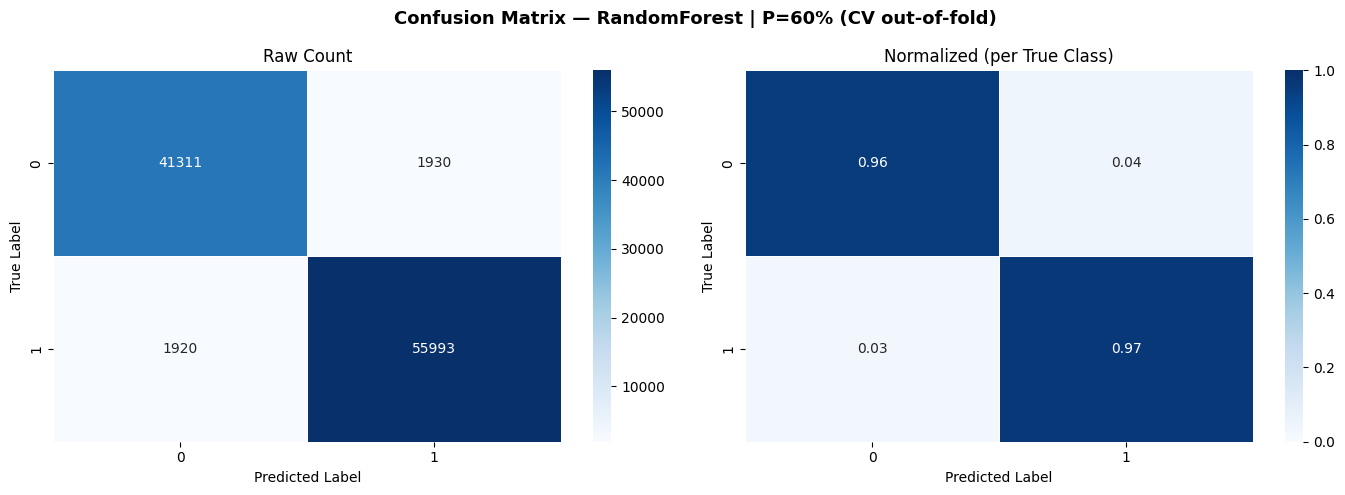


  Classification Report (Hold-out Test) — RandomForest, P=60%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



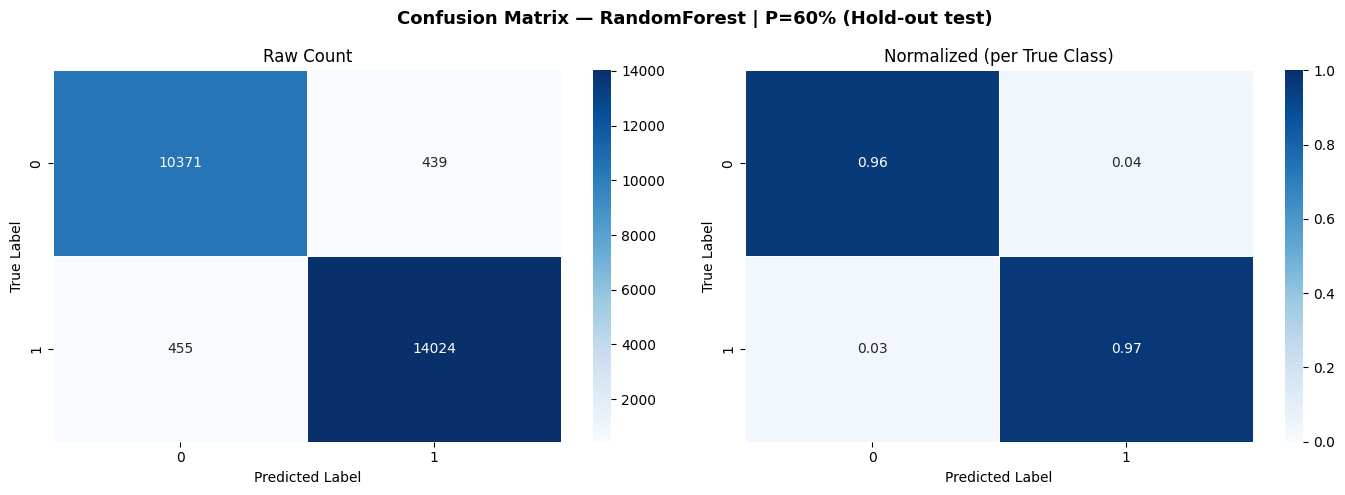


  Persentil P=70% -> 133 fitur

  [XGBoost]
  CV Time (5-fold) : 291.1262s

  Skor per fold — XGBoost, P=70%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9604    0.9595       0.9603           0.9601        0.9588
    2          20231    0.9590    0.9580       0.9589           0.9590        0.9571
    3          20231    0.9615    0.9607       0.9615           0.9612        0.9602
    4          20231    0.9594    0.9585       0.9594           0.9588        0.9582
    5          20230    0.9607    0.9598       0.9606           0.9604        0.9591

  Classification Report (CV, out-of-fold) — XGBoost, P=70%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96   

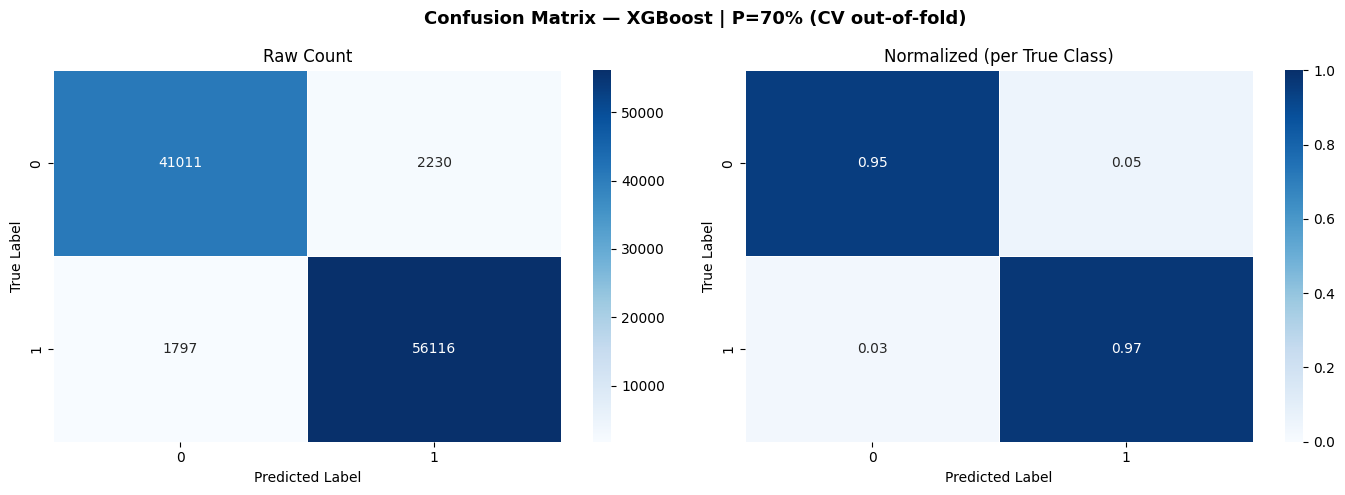


  Classification Report (Hold-out Test) — XGBoost, P=70%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



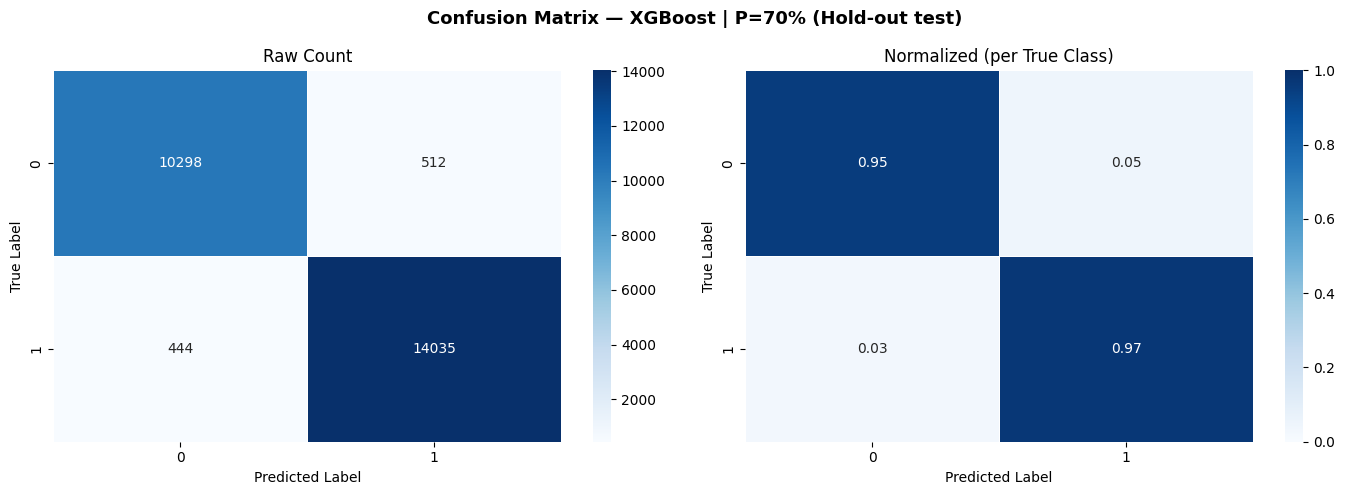


  [LightGBM]


/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/muhammadzuamaalamin/Documents/PengamanJar

  CV Time (5-fold) : 289.8654s

  Skor per fold — LightGBM, P=70%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9603    0.9594       0.9603           0.9601        0.9588
    2          20231    0.9595    0.9586       0.9595           0.9595        0.9578
    3          20231    0.9605    0.9596       0.9604           0.9599        0.9592
    4          20231    0.9598    0.9589       0.9598           0.9591        0.9587
    5          20230    0.9604    0.9594       0.9603           0.9601        0.9588

  Classification Report (CV, out-of-fold) — LightGBM, P=70%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     43241
           1       0.96      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



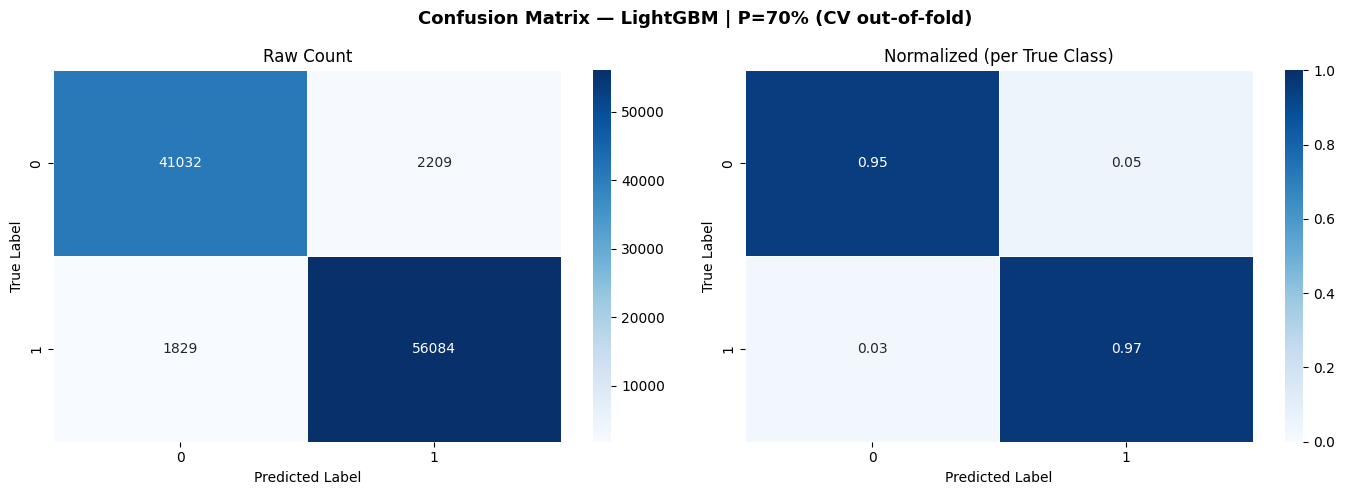


  Classification Report (Hold-out Test) — LightGBM, P=70%:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10810
           1       0.96      0.97      0.97     14479

    accuracy                           0.96     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.96      0.96      0.96     25289



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


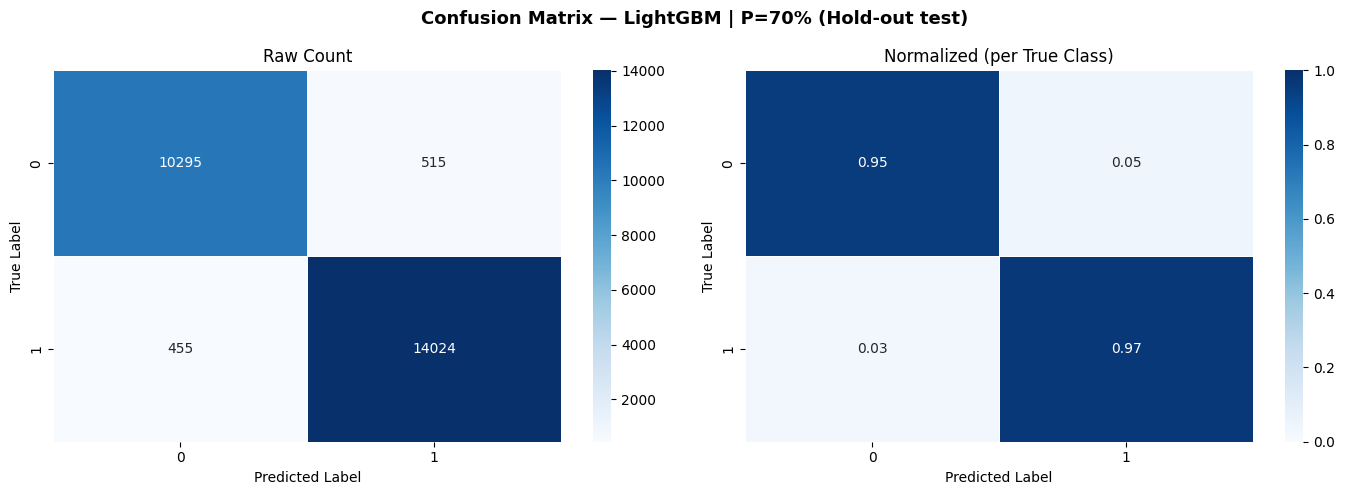


  [RandomForest]
  CV Time (5-fold) : 379.5307s

  Skor per fold — RandomForest, P=70%:
 Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
    1          20231    0.9624    0.9616       0.9624           0.9617        0.9614
    2          20231    0.9616    0.9608       0.9616           0.9610        0.9606
    3          20231    0.9630    0.9622       0.9630           0.9621        0.9624
    4          20231    0.9622    0.9615       0.9622           0.9611        0.9618
    5          20230    0.9623    0.9615       0.9623           0.9615        0.9615

  Classification Report (CV, out-of-fold) — RandomForest, P=70%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     43241
           1       0.97      0.97      0.97     57913

    accuracy                           0.96    101154
   macro avg       0.96      0.96      0.96    101154
weighted avg       0.96      0.96      0.96    101154



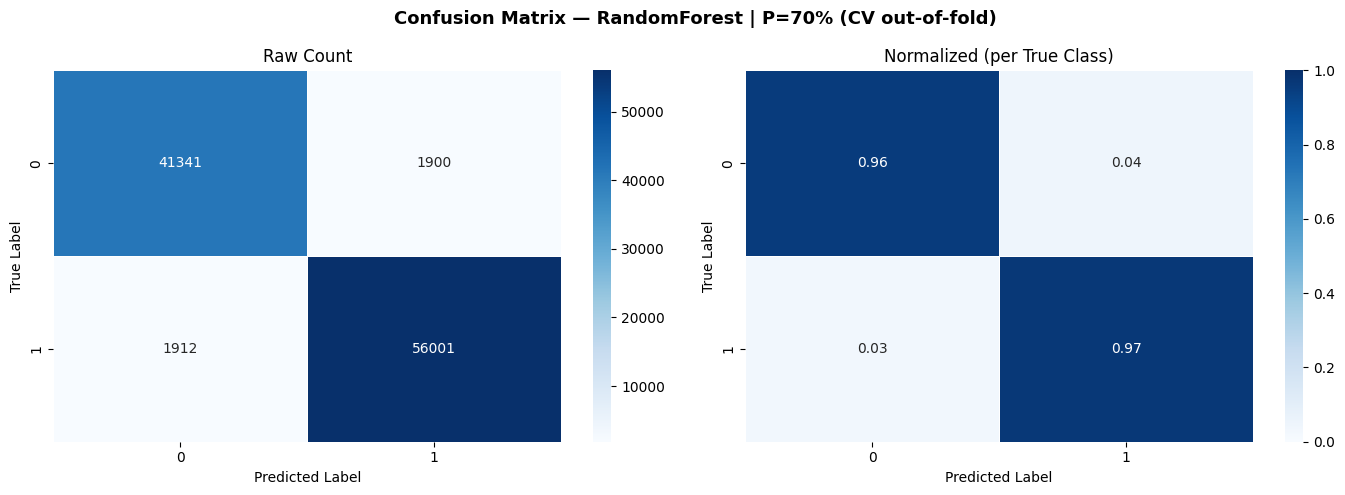


  Classification Report (Hold-out Test) — RandomForest, P=70%:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     10810
           1       0.97      0.97      0.97     14479

    accuracy                           0.97     25289
   macro avg       0.96      0.96      0.96     25289
weighted avg       0.97      0.97      0.97     25289



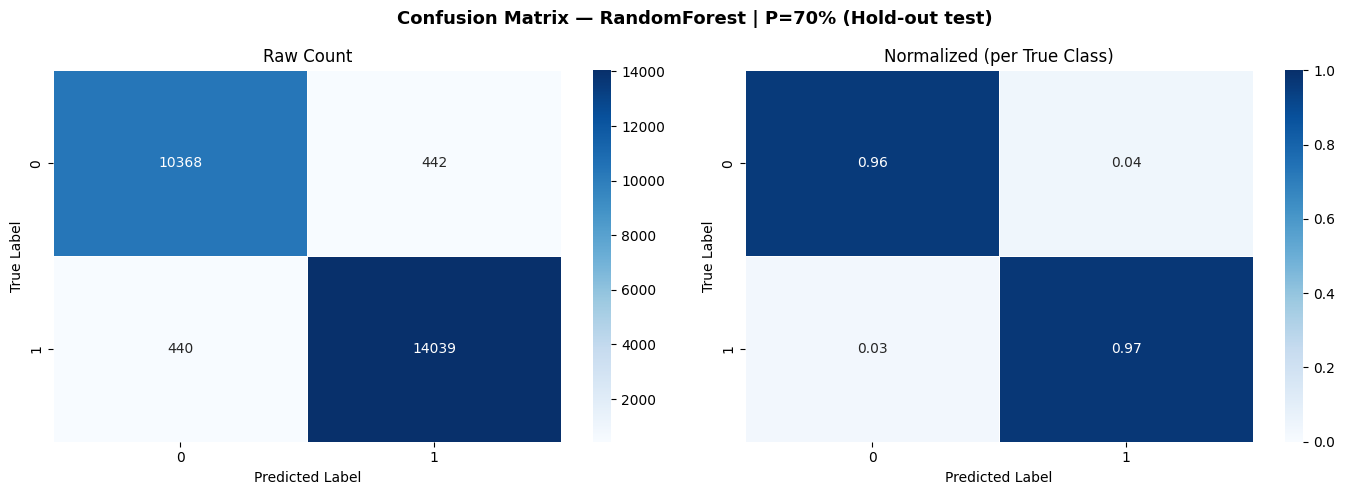

  PERSENTIL+SMOTETOMEK — SKOR PER FOLD, SEMUA KOMBINASI (long-format)
 Group  N Fitur        Model  Fold  N Val Samples  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Precision Weighted  Recall Macro  Recall Weighted
    10       19      XGBoost     1          20231    0.9458    0.9447       0.9458           0.9447              0.9458        0.9446           0.9458
    10       19      XGBoost     2          20231    0.9478    0.9465       0.9477           0.9474              0.9477        0.9457           0.9478
    10       19      XGBoost     3          20231    0.9498    0.9487       0.9498           0.9486              0.9498        0.9489           0.9498
    10       19      XGBoost     4          20231    0.9489    0.9479       0.9489           0.9478              0.9489        0.9479           0.9489
    10       19      XGBoost     5          20230    0.9497    0.9485       0.9496           0.9491              0.9496        0.9480           0.9497
    10       19     Ligh

In [12]:

 
# %% [markdown]
# ## 6. Loop Persentil Fitur x Model — SMOTETomek + Stratified K-Fold CV
#
# Untuk setiap persentil fitur teratas (berdasarkan SHAP importance) dan
# setiap model, pipeline `resampling -> scaling -> classifier` dievaluasi
# dengan CV manual per-fold (anti data leakage), lalu juga dievaluasi di
# hold-out test set.
 
# %%
percentiles = [10, 20, 30, 40, 50, 60, 70]
 
fs_models = {
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=7, learning_rate=0.2, random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=None, learning_rate=0.2,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=5,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
}
 
results_cv = {}
results_holdout = {}
cv_perfold_records = []
 
for P in percentiles:
    N_total = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))
    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()
 
    X_train_p = X_train[selected_features]
    X_test_p = X_test[selected_features]
 
    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% -> {N_FEATURES} fitur")
    print(f"{'='*60}")
 
    for model_name, clf in fs_models.items():
        print(f"\n  [{model_name}]")
 
        # Resampling & scaling HANYA melihat fold training di tiap iterasi CV
        steps = [
            ("resampling", SMOTETomek(random_state=RANDOM_STATE)),
            ("scaler", MinMaxScaler()),
            ("classifier", clf.__class__(**clf.get_params())),
        ]
 
        start = time.time()
        y_pred_cv, fold_records = run_manual_cv(
            steps, X_train_p, y_train, skf,
            group_label=P, n_features=N_FEATURES, model_name=model_name
        )
        cv_time = time.time() - start
        print(f"  CV Time ({N_SPLITS}-fold) : {cv_time:.4f}s")
 
        cv_perfold_records.extend(fold_records)
 
        # Tampilkan skor tiap fold (bukan cuma rata-rata) untuk kombinasi ini
        fold_preview_df = pd.DataFrame(fold_records).round(4)
        print(f"\n  Skor per fold — {model_name}, P={P}%:")
        print(fold_preview_df[[
            'Fold', 'N Val Samples', 'Accuracy', 'F1 Macro', 'F1 Weighted',
            'Precision Macro', 'Recall Macro'
        ]].to_string(index=False))
 
        print(f"\n  Classification Report (CV, out-of-fold) — {model_name}, P={P}%:")
        print(classification_report(y_train, y_pred_cv,
                                      target_names=[str(c) for c in class_labels], zero_division=0))
        plot_confusion_matrix(y_train, y_pred_cv,
                               f'Confusion Matrix — {model_name} | P={P}% (CV out-of-fold)', class_labels)
 
        results_cv[f'P{P}_{model_name}'] = summarize_cv_report(
            y_train, y_pred_cv, fold_records, P, N_FEATURES, model_name, cv_time
        )
 
        holdout_result, y_pred_test = evaluate_holdout(
            steps, X_train_p, y_train, X_test_p, y_test, P, N_FEATURES, model_name
        )
        results_holdout[f'P{P}_{model_name}'] = holdout_result
 
        print(f"\n  Classification Report (Hold-out Test) — {model_name}, P={P}%:")
        print(classification_report(y_test, y_pred_test,
                                      target_names=[str(c) for c in class_labels], zero_division=0))
        plot_confusion_matrix(y_test, y_pred_test,
                               f'Confusion Matrix — {model_name} | P={P}% (Hold-out test)', class_labels)
 
# %%
cv_perfold_df = pd.DataFrame(cv_perfold_records).round(4)
cv_perfold_df = cv_perfold_df[[
    'Group', 'N Fitur', 'Model', 'Fold', 'N Val Samples',
    'Accuracy', 'F1 Macro', 'F1 Weighted',
    'Precision Macro', 'Precision Weighted', 'Recall Macro', 'Recall Weighted'
]]
 
results_cv_df = pd.DataFrame(results_cv).T.round(4)
results_holdout_df = pd.DataFrame(results_holdout).T.round(4)
 
print("="*70)
print("  PERSENTIL+SMOTETOMEK — SKOR PER FOLD, SEMUA KOMBINASI (long-format)")
print("="*70)
print(cv_perfold_df.to_string(index=False))
 
print("\n" + "="*70)
print("  PERSENTIL+SMOTETOMEK — RATA-RATA CV PER KOMBINASI")
print("="*70)
print(results_cv_df.sort_values('F1 Macro', ascending=False).to_string())
 
best_cv = results_cv_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik (CV F1 Macro): Persentil={best_cv['Group']}%, "
      f"Model={best_cv['Model']}, F1 Macro={best_cv['F1 Macro']} "
      f"(std antar fold={best_cv['F1 Macro Std (antar fold)']})")
 
print("\n" + "="*70)
print("  PERSENTIL+SMOTETOMEK — HOLD-OUT TEST SET PER KOMBINASI")
print("="*70)
print(results_holdout_df.sort_values('F1 Macro', ascending=False).to_string())
 
best_holdout = results_holdout_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik (Hold-out F1 Macro): Persentil={best_holdout['Group']}%, "
      f"Model={best_holdout['Model']}, F1 Macro={best_holdout['F1 Macro']}")
 
# %%
comparison_df = pd.DataFrame({
    'F1 Macro (CV, rata-rata)' : results_cv_df['F1 Macro'],
    'F1 Macro (Hold-out)'      : results_holdout_df['F1 Macro'],
}).round(4)
comparison_df['Selisih'] = (
    comparison_df['F1 Macro (CV, rata-rata)'] - comparison_df['F1 Macro (Hold-out)']
).round(4)
 
print("="*70)
print("  PERBANDINGAN SKOR CV vs HOLD-OUT (cek konsistensi / overfitting)")
print("="*70)
print(comparison_df.sort_values('F1 Macro (CV, rata-rata)', ascending=False).to_string())
 
 
# %% [markdown]
# ## 7. Gabungan Baseline + Persentil — Tabel Statistik & Ekspor CSV
#
# `all_perfold_df` menggabungkan skor per-fold dari Baseline (Bagian 4) dan
# semua kombinasi Persentil+SMOTETomek (Bagian 6) dalam satu tabel
# long-format. Karena `skf` (fold split) sama untuk semua eksperimen
# (`random_state` & `n_splits` identik), perbandingan antar baris yang
# fold-nya sejajar bisa dipakai untuk **paired t-test**; perbandingan
# antar grup (model/persentil) secara umum bisa dipakai untuk **ANOVA**.
 
# %%
all_perfold_df = pd.concat([baseline_perfold_df, cv_perfold_df], ignore_index=True)
 
print(f"Total baris: {len(all_perfold_df)} "
      f"(Baseline: {len(baseline_perfold_df)}, Persentil+SMOTETomek: {len(cv_perfold_df)})")
 
all_perfold_csv_path = os.path.join(OUTPUT_DIR, "all_perfold_scores.csv")
all_perfold_df.to_csv(all_perfold_csv_path, index=False)
print(f"Disimpan ke: {all_perfold_csv_path}")
 
print("\nRingkasan deskriptif F1 Macro per Model (across semua fold & grup):")
print(all_perfold_df.groupby('Model')['F1 Macro'].agg(['mean', 'std', 'min', 'max']).round(4).to_string())
 
print("\nRingkasan deskriptif F1 Macro per Group (Baseline vs tiap persentil):")
print(all_perfold_df.groupby('Group')['F1 Macro'].agg(['mean', 'std', 'min', 'max']).round(4).to_string())
 